In [ ]:
!pip install -q -U google-generativeai
!pip list | grep google
!pip install gspread-dataframe
!pip install gspread_pandas
!pip install googletrans==3.1.0a0
!pip install --upgrade --user --quiet google-cloud-aiplatform rouge_score plotly jsonlines
!pip install --upgrade google-cloud-aiplatform

google                                2.0.3
google-ai-generativelanguage          0.6.15
google-api-core                       2.25.1
google-api-python-client              2.173.0
google-auth                           2.38.0
google-auth-httplib2                  0.2.0
google-auth-oauthlib                  1.2.2
google-cloud-aiplatform               1.98.0
google-cloud-bigquery                 3.34.0
google-cloud-bigquery-connection      1.18.3
google-cloud-bigquery-storage         2.32.0
google-cloud-core                     2.4.3
google-cloud-dataproc                 5.20.0
google-cloud-datastore                2.21.0
google-cloud-firestore                2.21.0
google-cloud-functions                1.20.4
google-cloud-iam                      2.19.1
google-cloud-language                 2.17.2
google-cloud-resource-manager         1.14.2
google-cloud-spanner                  3.55.0
google-cloud-storage                  2.19.0
google-cloud-translate                3.20.3
google-colab 

In [ ]:
import sys
if "google.colab" in sys.modules:
    import IPython

    app = IPython.Application.instance()
    app.kernel.do_shutdown(True)

#please restart the colab

In [ ]:
import sys
if "google.colab" in sys.modules:
    from google.colab import auth
    auth.authenticate_user()

## Set up your API key

To use the Gemini API, you'll need an API key. If you don't already have one, create a key in Google AI Studio.

<a class="button" href="https://aistudio.google.com/app/apikey" target="_blank" rel="noopener noreferrer">Get an API key</a>

In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GOOGLE_API_KEY`. Then pass the key to the SDK:


# Please change to your project Gemini API

In [ ]:
# Import the Python SDK
import googletrans
from googletrans import Translator
import pandas as pd
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata
import googlesearch as g
import time
from google.colab import auth
auth.authenticate_user()
import gspread_pandas
from google.auth import default
import pandas as pd
import gspread
from vertexai.preview.tuning import sft
from vertexai.generative_models import (
    GenerationConfig,
    GenerativeModel,
    HarmBlockThreshold,
    HarmCategory,
    SafetySetting
)
translator = Translator()


GOOGLE_API_KEY= '' # @param {isTemplate: true}
genai.configure(api_key=GOOGLE_API_KEY)

def split_by_element(lst, element):
    """Splits a list into sublists whenever the given element is found."""
    result = []
    current_sublist = []
    for item in lst:
        if item == element:
            if current_sublist:  # Don't add empty sublists
                result.append(current_sublist)
            current_sublist = []
        else:
            current_sublist.append(item)
    if current_sublist:  # Append any remaining elements
        result.append(current_sublist)
    return result

model_version  = 'gemini-2.5-flash' # @param {isTemplate: true}
generation_config = {'temperature': 0.01, 'top_p': 0.95} # @param {isTemplate: true
model = genai.GenerativeModel(f'{model_version}')
safety_settings = [
    {
        "category": "HARM_CATEGORY_DANGEROUS",
        "threshold": "BLOCK_NONE",
    },
    {
        "category": "HARM_CATEGORY_HARASSMENT",
        "threshold": "BLOCK_NONE",
    },
    {
        "category": "HARM_CATEGORY_HATE_SPEECH",
        "threshold": "BLOCK_NONE",
    },
    {
        "category": "HARM_CATEGORY_SEXUALLY_EXPLICIT",
        "threshold": "BLOCK_NONE",
    },
    {
        "category": "HARM_CATEGORY_DANGEROUS_CONTENT",
        "threshold": "BLOCK_NONE",
    },
]

# Add Domain Defintiion

In [ ]:
#Add definition
sheet_url = 'https://docs.google.com/spreadsheets/d/1j1YiuTFEwIwxcJ446vkT-xlPbqCAlha1oxnO7eyDQlo/edit?resourcekey=0-cOKdZ5SSOwaP2L_RabpS0Q&gid=0#gid=0'
creds, _ = default()
gc = gspread.authorize(creds)
# Replace with your actual sheet URL
sheet_url = sheet_url
# Open the spreadsheet
sh = gc.open_by_url(sheet_url)
# Select the worksheet (replace 'Sheet1' with the actual sheet name if needed)
worksheet = sh.worksheet('train')
data = worksheet.get_all_values()
df_definition1 = pd.DataFrame(data[1:], columns=data[0])
df_definition1 = df_definition1[df_definition1['language_code'] =='en']
# Print the DataFrame (optional)
df_def = df_definition1[['Domain','Definition']].drop_duplicates()


#Add definition
sheet_url = 'https://docs.google.com/spreadsheets/d/1j1YiuTFEwIwxcJ446vkT-xlPbqCAlha1oxnO7eyDQlo/edit?resourcekey=0-cOKdZ5SSOwaP2L_RabpS0Q&gid=0#gid=0'
creds, _ = default()
gc = gspread.authorize(creds)
# Replace with your actual sheet URL
sheet_url = sheet_url
# Open the spreadsheet
sh = gc.open_by_url(sheet_url)
# Select the worksheet (replace 'Sheet1' with the actual sheet name if needed)
worksheet = sh.worksheet('test')
data = worksheet.get_all_values()
df_definition2 = pd.DataFrame(data[1:], columns=data[0])
df_definition2 = df_definition2[df_definition1['language_code'] =='en']
# Print the DataFrame (optional)
df_def2 = df_definition2[['Domain','Definition']].drop_duplicates()
df_def_all = pd.concat([df_def,df_def2 ])

In [ ]:
#@title Import the Excel to Colab after Review  - Run this cell meaning we are updating the previous url reviewed result to the Colab
sheet_url = 'https://docs.google.com/spreadsheets/d/1Fg35l5vEgcUaeqPQgX0pJ8slZc1tWeknmkqDla0zUfg/edit?gid=2068367434#gid=2068367434'
creds, _ = default()
gc = gspread.authorize(creds)
# Replace with your actual sheet URL
sheet_url = sheet_url
# Open the spreadsheet
sh = gc.open_by_url(sheet_url)
# Select the worksheet (replace 'Sheet1' with the actual sheet name if needed)
worksheet = sh.worksheet('[validated] Terms')
data = worksheet.get_all_values()
df_validated = pd.DataFrame(data[1:], columns=data[0])
# Print the DataFrame (optional)
df_validated = df_validated[['Policy','Dimension','Topic','Topic Definition','Terms']]
df_validated.columns = ['Domain','level1','level2','Topic Definition','level3']
df_validated

# add education reviewed source

In [ ]:
#@title Import the Excel to Colab after Review  - Run this cell meaning we are updating the previous url reviewed result to the Colab
sheet_url = 'https://docs.google.com/spreadsheets/d/1lP-R-XbX5RgnrPPdghKZn_vSIcy_qxStE7yLJSCF1q8/edit?resourcekey=0-2xIqQty2VOqWyXtj-WyFRA&gid=1694145616#gid=1694145616'
creds, _ = default()
gc = gspread.authorize(creds)
# Replace with your actual sheet URL
sheet_url = sheet_url
# Open the spreadsheet
sh = gc.open_by_url(sheet_url)
# Select the worksheet (replace 'Sheet1' with the actual sheet name if needed)
worksheet = sh.worksheet('Train')
data = worksheet.get_all_values()
df_edu= pd.DataFrame(data[1:], columns=data[0])
# Print the DataFrame (optional)
df_edu

## Know your language code

# 1) Generate Topics

In [ ]:
#@title #Language Code version
#generate result
x = ''
def prompt_function(i,j,t,Country,Language_code, Definition):
  if Country == 'ALL':
    prompt_terms = f'''
            List the top 3 English keywords that most related to topic {t} given that the topic is sourced from and all the keywords are all related to {i} {j} given the definition of the domain is {Definition},
            please only output 3 words without explainations but add rationale after the third words for example given topic germs that related to hate speech dehumanization, please do not generate duplicate words with {t} and {i}{j},
            and please strictly stick to the below output format
            the expected output of 3 keywords would be: 1. Vermin, 2. Disease, 3. Filth; Rationale: ....
    '''
    if Language_code == 'en':
      prompt_terms = prompt_terms
    else:
      translated_ita = translator.translate(prompt_terms, src='en', dest=f'{Language_code}')
      prompt_terms = translated_ita.text
  else:
     prompt_terms = f'''List the top 3 keywords that most related to topic {t} given that the topic is sourced from and all the keywords are all related to {i} {j} in {Country} given the definition of the domain is {Definition},
            please only output 3 words without explainations but add rationale after the third words for example given topic germs that related to hate speech dehumanization, please do not generate duplicate words with {t} and {i}{j},
            and please strictly stick to the below output format
            the expected output of 3 keywords would be: 1. Vermin, 2. Disease, 3. Filth; Rationale: ....
     '''
     if Language_code == 'en':
       prompt_terms = prompt_terms
     else:
       translated_ita = translator.translate(prompt_terms, src='en', dest=f'{Language_code}')
       prompt_terms = translated_ita.text
  return prompt_terms

def pipeline_run(domain, Country, Language_code, Definition):
  domain = domain # @param {isTemplate: true}
  #Example = 'For hate speech one of the categories is dehumanization, and its topic expected would be subhuman, belittling, animals, germs, insect, bacteria, or another category could be Stereotyping, its corresponding topics would be listed as Prejudice,Bigotry,Discrimination,Labeling,Categorizing, Essentializing' # @param {isTemplate: true}
  level1_a = 'dehumanization' # @param {isTemplate: true}
  level2_a = 'Subhuman, belittling, animals, germs, insect, bacteria' # @param {isTemplate: true}

  level1_b = 'Public Health and Safety' # @param {isTemplate: true}
  level2_b = 'Healthcare Policies,Disease Prevention,Public Health Initiatives, Healthcare Access' # @param {isTemplate: true}

  Country = Country # @param {isTemplate: true}
  Language_code = Language_code #Please enter language code from previous session #@param {isTemplate: true}

  policy = domain
  translator = Translator()
  if Country == 'ALL':
    prompt = f'''You are a policy expert. Please analyze {policy} and provide a comprehensive list of categories and corresponding topics related to this domain given the definition of this domain is {Definition}.

                  Do not hallucinate or invent any links or sources.
                  If no actual links/sources are available, provide a clear and well-supported rationale for the generated topics and categories.
                  Strive for comprehensiveness in your analysis, covering a wide range of relevant perspectives and issues related to {policy}.

                  For example, your output please strictly follow the same format below（Category, Topics, Rationale） and do not add any more session besides Category, Topics, Rationale and keep the sequence of the session first say Category,then Topics, and Rationale, please do not add any more stuff, the format should EXACTLY look like the examples format below:

                Examples:
                    for hate speech domain,
                    Category: {level1_a}` (replace `{level1_a}` with your chosen category)
                    Topics: {level2_a}` (replace `{level2_a}` with the relevant topics for that category)
                    Rationale: [Explanation of why this category and topic are relevant to this domain , including links/sources if available]

                  for public interest domain,
                  Category: {level1_b}
                  Topics: {level2_b}
                  Rationale: [Explanation of why this category and topic are relevant to this domain, including actual links/sources if available, or a detailed rationale for generating these topics.]

                Notes:
                1. Check if all relevant categories and topics related to `{policy}` have been covered and aligned with the defintion {Definition}. If not, go back to step 2 and create another category entry using the same format, making sure there is always ":" following each key session such as Category:, Topics:, Rationale: ; please do not add "(" or ")" in the output.
                Continue this loop until you believe all significant aspects are addressed. Each iteration should add a new category entry. The loop terminates when a comprehensive list is created. Please making sure we include the example categories too
                2. Review the complete output to ensure it adheres strictly to the specified format and contains no hallucinations or invented information. do not limit yourself to specific number of categories to output, as long as its relevant and have sourced it should be included as long as not from hallucination
                Ensure all rationales are well-supported and clearly explain the relevance of each category and topic to the policy within the specified country.
                3. Output the complete list of categories, topics, and rationales in the specified format.

                  ... (repeat for each category)

                                      '''
  else:
    prompt = f'''
                As a policy expert specializing in {Country}, your task is to analyze the theme {policy} and provide a categorized list of relevant topics that specifically affect {Country} in this domain given the definition of this domain is {Definition}.
                Your output should strictly adhere to the specified format: (Category, Topics, Rationale). The rationale should explain the relevance of each category and topic to the policy within {Country},
                including citations or links in {Language_code} if available. Do not add any additional sessions or information beyond the requested format.

                # Step by Step instructions:
                1. Read the provided `Intent`, `Variable Names`, and `Other Context` sections carefully. Extract the values for `{Country}`, `{policy}`, and `{Language_code}`.
                Note that the `Other Context` provides an example format, but the instruction is to *only* use the format specified in the `Intent` section.
                2. Based on your knowledge of the specified `{Country}` and `{policy}`, brainstorm relevant categories and corresponding topics, etc.)
                that are specifically impacted by the policy within that country.
                3. The `Intent` section explicitly specifies the desired output format: `(Category, Topics, Rationale)`. Therefore, no other format needs to be considered.
                4. your output please strictly follow the same format below（Category, Topics, Rationale） and do not add any more session besides Category, Topics, Rationale and keep the sequence of the session first say Category,then Topics, and Rationale, please do not add any more stuff, the format should EXACTLY look like the examples format below:

                Examples:
                    for hate speech domain,
                    Category: {level1_a}` (replace `{level1_a}` with your chosen category)
                    Topics: {level2_a}` (replace `{level2_a}` with the relevant topics for that category)
                    Rationale: [Explanation of why this category and topic are relevant to this domain in {Country}, including links/sources in {Language_code} if available]

                    for public interest domain,
                    Category: {level1_b}
                    Topics: {level2_b}
                    Rationale: [Explanation of why this category and topic are relevant to this domain, including actual links/sources if available, or a detailed rationale for generating these topics.]


                5. Check if all relevant categories and topics related to `{policy}` in `{Country}` have been covered and aligned with the defintion {Definition}. If not, go back to step 2 and create another category entry using the same format, making sure there is always ":" following each key session such as Category:, Topics:, Rationale: ; please do not add "(" or ")" in the output.
                Continue this loop until you believe all significant aspects are addressed. Each iteration should add a new category entry. The loop terminates when a comprehensive list is created.Please making sure we include the example categories too
                6. Review the complete output to ensure it adheres strictly to the specified format and contains no hallucinations or invented information.
                Ensure all rationales are well-supported and clearly explain the relevance of each category and topic to the policy within the specified country.
                7. Output the complete list of categories, topics, and rationales in the specified format.




                                ...
                                      '''
  if Language_code == 'en':
    prompt = prompt
  else:
    translated_ita = translator.translate(prompt, src='en', dest=f'{Language_code}')
    prompt = translated_ita.text
  list2 = []
  response = model.generate_content(prompt, safety_settings = safety_settings,request_options={"timeout": 1800})
  result = response.text
  list2.append(result)
  list_split = list(list2[0].split('\n'))
  list_final = split_by_element(list_split, '')[0:]
  df_final = pd.DataFrame()
  for i in list_final[0:]:
    df = pd.DataFrame()
    df['topic'] = [i[1]]
    df['categories'] = [i[0]]
    df['rationale'] = [i[2]]
    df_final = pd.concat([df_final, df])

  df_final['topic'] = df_final['topic'].apply(lambda x: x.lower().replace('* ', '').replace('*', '').replace('topics:','').replace('themes:','').replace('topic:','').replace('theme:',''))
  df_final['categories'] = df_final['categories'].apply(lambda x: x.replace('*', '').replace('Category:','').replace('category:',''))
  df_final['rationale'] = df_final['rationale'].apply(lambda x: x.lower().replace('*', '').replace('rationale:','').replace('reasons:','').replace('reason:',''))
  df_final['domain'] = translator.translate(domain, src='en', dest=f'{Language_code}').text
  df_final['categories'] = df_final['categories'].apply(lambda x: x.replace('Category:','').replace('-',''))
  df_final['topic'] = df_final['topic'].str.split(', ')
  df_final = df_final.explode('topic', ignore_index=True)
  df_final['topic'] = df_final['topic'].apply(lambda x: x.replace('Topics:',''))
  df_final['country'] = Country
  df_final['language_code'] = Language_code
  df_final['Definition'] = Definition
  df_final = df_final[['domain', 'categories', 'topic',  'country', 'language_code','rationale','Definition']]
  df_final.columns = ['domain', 'level1', 'level2',  'country', 'language_code','rationale','Definition']
  list_1 = []
  list_2 = []
  for i,j,t,d in zip(df_final.domain,df_final.level1,df_final.level2,df_final.Definition):
    response = model.generate_content(prompt_function(i,j,t,Country,Language_code, d), safety_settings=safety_settings,request_options={"timeout": 1800})
    result = response.text
    #result = translator.translate(result, src=f'{Language_code}', dest='en').text
    try:
      list_term = [list([list(result.split('1.'))[1].split('2.')[0].replace(":", "").replace('\n',''), list(result.split('2.'))[1].split('3.')[0].replace(":", "").replace('\n',''),list(result.split('3.'))[1].replace(":", "").replace('\n','')])]
      list_1.append(list_term)
      list_2.append(t)
    except:
      pass
  df_term_gen = pd.DataFrame()
  df_term_gen['list_1'] = list_1
  df_term_gen['list_2'] = list_2
  df_term_gen.columns = ['level3', 'level2']
  df_demo_1 = df_final.merge(df_term_gen,how='left', on='level2')
  df_demo_1['level3'] = df_demo_1['level3'].apply(lambda x: str(x).replace('[', '').replace(']', '').replace('*',''))
  df_demo_1[['level3', 'rationale_for_level3']] = df_demo_1['level3'].str.split(';', n=1, expand=True)
  return df_demo_1

####@title Export the result to drive for Review;   Please change the name each time
trix_name = 'SARA Data for sft'  #@param {isTemplate: true}
creds, _ = default()
spread = gspread_pandas.Spread(f'{trix_name}', creds=creds, create_spread=True)
spread.df_to_sheet(df_all, index=False, headers=True, start='A1',)
# Get the sheet URL
sheet_url = spread.url
print("Sheet URL:", sheet_url)

In [ ]:
#@title Import the Excel to Colab after Review  - Run this cell meaning we are updating the previous url reviewed result to the Colab
creds, _ = default()
gc = gspread.authorize(creds)
# Replace with your actual sheet URL
sheet_url = 'https://docs.google.com/spreadsheets/d/1cAMRIvl41bPKCR2vueyD2vYLqtX2RS-pPyq6PJcl7As/edit?resourcekey=0-K14MpKqLQnbz8UqFOrBYig&gid=0#gid=0'
# Open the spreadsheet
sh = gc.open_by_url(sheet_url)
# Select the worksheet (replace 'Sheet1' with the actual sheet name if needed)
worksheet = sh.worksheet('First Batch Review')
data = worksheet.get_all_values()
df_reviewed = pd.DataFrame(data[1:], columns=data[0])
# Print the DataFrame (optional)
#@title Import the Excel to Colab after Review  - Run this cell meaning we are updating the previous url reviewed result to the Colab
creds, _ = default()
gc = gspread.authorize(creds)
# Replace with your actual sheet URL
sheet_url = 'https://docs.google.com/spreadsheets/d/1cAMRIvl41bPKCR2vueyD2vYLqtX2RS-pPyq6PJcl7As/edit?resourcekey=0-K14MpKqLQnbz8UqFOrBYig&gid=0#gid=0'
# Open the spreadsheet
sh = gc.open_by_url(sheet_url)
# Select the worksheet (replace 'Sheet1' with the actual sheet name if needed)
worksheet = sh.worksheet('Second Batch Review')
data = worksheet.get_all_values()
df_reviewed_second_batch = pd.DataFrame(data[1:], columns=data[0])
# Print the DataFrame (optional)
df_reviewed_second_batch

In [ ]:
def translate_if_not_agree(row):
  if row['if you do then enter agree, if do not agree then enter alternative l3 for replacement'] != 'Agree':
    translated = translator.translate(row['if you do then enter agree, if do not agree then enter alternative l3 for replacement'], src='en', dest=row['language_code']).text
    return translated
  else:
    return row['if you do then enter agree, if do not agree then enter alternative l3 for replacement']  # Keep original value if it's 'Agree'

df_reviewed_second_batch['if you do then enter agree, if do not agree then enter alternative l3 for replacement'] = df_reviewed_second_batch.apply(translate_if_not_agree, axis=1)
df_reviewed['if you do then enter agree, if do not agree then enter alternative l3 for replacement'] = df_reviewed.apply(translate_if_not_agree, axis=1)
df_reviewed

In [ ]:
df_reviewed_second_batch['Translated level1'] = df_reviewed_second_batch.apply(lambda x: x['level1'] if x['Translated level1'] == '' else x['Translated level1'], axis = 1 )
df_reviewed_second_batch['Translated level2'] = df_reviewed_second_batch.apply(lambda x: x['level2'] if x['Translated level2'] == '' else x['Translated level2'], axis = 1 )
df_reviewed_second_batch['Translated level3'] = df_reviewed_second_batch.apply(lambda x: x['level3'] if x['Translated level3'] == '' else x['Translated level3'], axis = 1 )
df_reviewed_second_batch['Processed_l3_agree'] =  df_reviewed_second_batch.apply(lambda x: x['if you do then enter agree, if do not agree then enter alternative l3 for replacement'] if x['if you do then enter agree, if do not agree then enter alternative l3 for replacement'] != 'Agree' else x['level3'], axis = 1)
df_reviewed_second_batch2 = df_reviewed_second_batch[['Domain', 'level1', 'level2',
       'country', 'language_code', 'level3', 'Translated level3', 'Processed_l3_agree','Domain translation']]
df_reviewed_second_batch2 = df_reviewed_second_batch2[~df_reviewed_second_batch2['Processed_l3_agree'].str.contains('unsure', case=False, na=False)]
df_reviewed_second_batch2['level3'] = df_reviewed_second_batch2['Processed_l3_agree']

df_reviewed['Translated level1'] = df_reviewed.apply(lambda x: x['level1'] if x['Translated level1'] == '' else x['Translated level1'], axis = 1 )
df_reviewed['Translated level2'] = df_reviewed.apply(lambda x: x['level2'] if x['Translated level2'] == '' else x['Translated level2'], axis = 1 )
df_reviewed['Translated level3'] = df_reviewed.apply(lambda x: x['level3'] if x['Translated level3'] == '' else x['Translated level3'], axis = 1 )
df_reviewed['Processed_l3_agree'] =  df_reviewed.apply(lambda x: x['if you do then enter agree, if do not agree then enter alternative l3 for replacement'] if x['if you do then enter agree, if do not agree then enter alternative l3 for replacement'] != 'Agree' else x['level3'], axis = 1)
df_reviewed2 = df_reviewed[['Domain', 'level1', 'level2',
       'country', 'language_code', 'level3', 'Translated level3', 'Processed_l3_agree','Translated Domain']]
df_reviewed2 = df_reviewed2[~df_reviewed2['Processed_l3_agree'].str.contains('unsure', case=False, na=False)]
df_reviewed2['level3'] = df_reviewed2['Processed_l3_agree']
df_reviewed2

In [ ]:
# Assuming your DataFrame is named 'df' and you have already imported necessary libraries and created a translator object
df_validated_list = df_validated.groupby(['Domain','level1', 'level2'])['level3'].apply(lambda x: ', '.join(x.astype(str))).reset_index()
df_validated_list.columns = ['Domain','level1','level2','level3']
df_validated_list['country'] = 'ALL'
df_validated_list['language_code'] = 'en'
df_validated_list = df_validated_list.merge(df_def_all, how = 'left', on = 'Domain')
df_reviewed2 = df_reviewed2.merge(df_def_all, how = 'left', left_on= 'Translated Domain' , right_on = 'Domain')
df_reviewed_second_batch2['Domain translation'] = df_reviewed_second_batch2.apply(lambda x: x['Domain'] if x['Domain translation'] == '' else x['Domain translation'], axis = 1 )
df_reviewed_second_batch2 = df_reviewed_second_batch2.merge(df_def_all, how = 'left', left_on = 'Domain translation', right_on = 'Domain')
df_reviewed2.rename(columns={'Domain_x': 'Domain'}, inplace=True)
df_reviewed_second_batch2.rename(columns={'Domain_x': 'Domain'}, inplace=True)
df_combine = pd.concat([df_reviewed2[['Domain','level1','level2','level3', 'country', 'language_code','Definition']],df_reviewed_second_batch2[['Domain','level1','level2','level3', 'country', 'language_code','Definition']] ,df_validated_list])

In [ ]:
# Iterate over each row of the dataframe and translate individually
for index, row in df_combine.iterrows():
    # Get the level1 and level2 values for this row
    level1_value = row['level1']
    level2_value = row['level2']
    level3_value = row['level3']
    defintion_value = row['Definition']

    # Get the destination language code for this row
    dest_language_code = row['language_code']

    # Translate the level1 value
    translated_level1 = translator.translate(level1_value,src = 'en', dest=dest_language_code).text
    df_combine.loc[index, 'level1_translated'] = translated_level1

    # Translate the level2 value
    translated_level2 = translator.translate(level2_value, src = 'en', dest=dest_language_code).text
    df_combine.loc[index, 'level2_translated'] = translated_level2

    translated_level3 = translator.translate(level3_value, src = 'en', dest=dest_language_code).text
    df_combine.loc[index, 'level3_translated'] = translated_level3

    translated_definition = translator.translate(defintion_value,src = 'en', dest=dest_language_code).text
    df_combine.loc[index, 'definition_translated'] = translated_definition

df_combine['level1_translated'] = df_combine.apply(lambda row: row['level1'] if row['language_code'] == 'en' else row['level1_translated'], axis=1)
df_combine['level2_translated'] = df_combine.apply(lambda row: row['level2'] if row['language_code'] == 'en' else row['level2_translated'], axis=1)
df_combine['level3_translated'] = df_combine.apply(lambda row: row['level3'] if row['language_code'] == 'en' else row['level3_translated'], axis=1)
df_combine['Definition_translated'] = df_combine.apply(lambda row: row['Definition'] if row['language_code'] == 'en' else row['definition_translated'], axis=1)

df_combine = df_combine[['Domain', 'level1_translated', 'level2_translated', 'level3_translated','level3', 'country', 'language_code','Definition_translated']]
df_combine.columns = ['Domain', 'level1', 'level2', 'level3_translated','level3', 'country', 'language_code','Definition']
df_combine = df_combine[df_combine['level3'] != 'N/A']
df_combine

In [ ]:
df_edu['country'] = 'ALL'
df_edu['language_code'] = 'en'
df_edu['level3_translated'] = df_edu['level3']
df_edu2 = df_edu[['Domain','level1','level2','level3_translated','level3','country','language_code','definition']]
df_edu2.columns = ['Domain','level1','level2','level3','level3_translated','country','language_code','Definition']
df_combine = pd.concat([df_combine,df_edu2])
df_combine = df_combine.dropna()
df_combine.reset_index(drop=True, inplace=True)
df_combine

In [ ]:
df_combine = df_combine[(df_combine['level3'] != '')& (df_combine['level3'] != '-')& (df_combine['level3'] != 'N/A')& (df_combine['Definition'] != 'Nan')]
df_combine

# fine tuning model

# devide to Train test data

In [ ]:
shuffled_df = df_combine.sample(frac=1, random_state=42)
# Calculate the split index
split_index = int(0.9 * len(df_combine))
# Split the DataFrame
df_train = shuffled_df[:split_index]
df_test = shuffled_df[split_index:]
df_train.to_json('Train_add_Second5.jsonl', orient='records', lines=True)
df_test.to_json('Test_add_Second5.jsonl', orient='records', lines=True)

# upload the reviewed csv from local to colab and convert to jsonl and upload to bucket in cloud

# import libraries

In [ ]:
import time
# For extracting vertex experiment details.
from google.cloud import aiplatform
from google.cloud.aiplatform.metadata import context
from google.cloud.aiplatform.metadata import utils as metadata_utils
import jsonlines # Now jsonlines should be available for import

# For data handling.
import pandas as pd

# For visualization.
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# For evaluation metric computation.
from rouge_score import rouge_scorer
from tqdm import tqdm

# For fine tuning Gemini model.
import vertexai
from vertexai.generative_models import (
    GenerationConfig,
    GenerativeModel,
    HarmBlockThreshold,
    HarmCategory,
)
from vertexai.preview.tuning import sft

PROJECT_ID = "project id"  # @param
LOCATION = "us-central1"  # @param

vertexai.init(project=PROJECT_ID, location=LOCATION)

# Provide a bucket name
BUCKET_NAME = ""  # @param {type:"string"}
BUCKET_URI = f"gs://{BUCKET_NAME}"
! gsutil mb -l {LOCATION} -p {PROJECT_ID} {BUCKET_URI}

Creating gs://bucket_sarai_2/...
ServiceException: 409 A Cloud Storage bucket named 'bucket_sarai_2' already exists. Try another name. Bucket names must be globally unique across all Google Cloud projects, including those outside of your organization.


In [ ]:
def save_jsonlines(file, instances):
    """
    Saves a list of json instances to a jsonlines file.
    """
    with jsonlines.open(file, mode="w") as writer:
        writer.write_all(instances)

def create_tuning_samples(file_path):
    """
    Creates tuning samples from a file.
    """
    with jsonlines.open(file_path) as reader:
        instances = []
        for obj in reader:
            instance = []
            for content in obj["messages"]:
                instance.append(
                    {"role": content["role"], "parts": [{"text": content["content"]}]}
                )
            instances.append({"contents": instance})
    return instances

In [ ]:
#train_file = "sft_train_samples.jsonl"
#train_instances = create_tuning_samples(train_file)
train_instances_domain_dimention = df_train[['Domain','level1','level2','level3','country','language_code','Definition']]
test_instances_domain_dimention = df_test[['Domain','level1','level2','level3','country','language_code','Definition']]

In [ ]:
x = ''
def prompt_function(i,j,t,Country,Language_code,Definition):
  if Country == 'ALL':
    prompt_terms = f'''
            List the top 3 English keywords that most related to topic {t} given that the topic is sourced from and all the keywords are all related to {i} {j} given the definition of the domain is {Definition},
            please only output 3 words without explainations but add rationale after the third words for example given topic germs that related to hate speech dehumanization,
            and please strictly stick to the below output format
            the expected output of 3 keywords would be: 1. Vermin, 2. Disease, 3. Filth; Rationale: ....

            Important Note: Please do not create keywords that duplicate with {i}{j}{t}
    '''
    if Language_code == 'en':
      prompt_terms = prompt_terms
    else:
      translated_ita = translator.translate(prompt_terms, src='en', dest=f'{Language_code}')
      prompt_terms = translated_ita.text
  else:
     prompt_terms = f'''List the top 3 keywords that most related to topic {t} given that the topic is sourced from and all the keywords are all related to {i} {j} in {Country} in language:{Language_code}(Language_code) given the definition of the domain is {Definition},
            please only output 3 words without explainations but add rationale after the third words for example given topic germs that related to hate speech dehumanization,
            and please strictly stick to the below output format
            the expected output of 3 keywords would be: 1. Vermin, 2. Disease, 3. Filth; Rationale: ....

            Important Note: Please do not create keywords that duplicate with {i}{j}{t}{Country}
     '''
     if Language_code == 'en':
       prompt_terms = prompt_terms
     else:
       translated_ita = translator.translate(prompt_terms, src='en', dest=f'{Language_code}')
       prompt_terms = translated_ita.text
  return prompt_terms

In [ ]:
def create_tuning_data(df):
    """
    Creates tuning data in the required format from the dataframe.
    """
    instances = []
    for _, row in df.iterrows():
        instance = [
           # {"role": "system", "parts": [{"text": f"Domain: {row['Domain']}"}]},
            {"role": "user", "parts": [{"text": prompt_function(row['Domain'],row['level1'],row['level2'],row['country'],row['language_code'],row['Definition'])}]},
            {"role": "model", "parts": [{"text": f"{row['level3']}"}]},
        ]
        instances.append({"contents": instance})
    return instances

# For train data
train_file = "Train_add_Second5.jsonl"
train_instances = create_tuning_data(df_train)
save_jsonlines(train_file, train_instances)

# For test data
val_file = "Test_add_Second5.jsonl"
val_instances = create_tuning_data(df_test)
save_jsonlines(val_file, val_instances)

In [ ]:
#train_file = "Train_public.jsonl"
#train_instances = create_tuning_samples(train_file)
len(train_instances)
# save the training instances to jsonl file
#save_jsonlines(train_file, train_instances)
#val_file = "Test_Danger.jsonl"
#val_instances = create_tuning_samples(val_file)
len(val_instances)
#save_jsonlines(val_file, val_instances)

268

# train model

In [ ]:
stats = df_test["Domain"].apply(len).describe()
print(f"Total `{stats['count']}` test records")
print(f"Average length is `{stats['mean']}` and max is `{stats['max']}` characters")
print("\nConsidering 1 token = 4 chars")

# Get ceil value of the tokens required.
tokens = (stats["max"] / 4).__ceil__()
max_output_tokens = tokens
print(
    f"\nSet max_token_length = stats['max']/4 = {stats['max']/4} ~ {tokens} characters"
)
print(f"\nLet's keep output tokens upto `{tokens}`")

Total `268.0` test records
Average length is `19.48507462686567` and max is `47.0` characters

Considering 1 token = 4 chars

Set max_token_length = stats['max']/4 = 11.75 ~ 12 characters

Let's keep output tokens upto `12`


In [ ]:
def l3_function(df_final):
    list_1 = []
    list_2 = []
    list_3 = []
    for i,j,t,c,l,d in set(zip(df_final.Domain,df_final.level1,df_final.level2,df_final.country,df_final.language_code, df_final.Definition)):
      response = model.generate_content(prompt_function(i,j,t,c,l,d), safety_settings=safety_settings,request_options={"timeout": 1800})
      result = response.text
      #result = translator.translate(result, src=f'{Language_code}', dest='en').text
      try:
        list_term = [list([list(result.split('1.'))[1].split('2.')[0].replace(":", "").replace('\n',''), list(result.split('2.'))[1].split('3.')[0].replace(":", "").replace('\n',''),list(result.split('3.'))[1].replace(":", "").replace('\n','')])]
        list_1.append(list_term)
        list_2.append(t)
        list_3.append(c)
      except:
        pass
    df_term_gen = pd.DataFrame()
    df_term_gen['list_1'] = list_1
    df_term_gen['list_2'] = list_2
    df_term_gen['country'] = list_3
    df_term_gen.columns = ['level3', 'level2','country']
    df_demo_1 = df_final.merge(df_term_gen,how='left', on=['level2','country'])
    df_demo_1['level3'] = df_demo_1['level3'].apply(lambda x: str(x).replace('[', '').replace(']', '').replace('*',''))
    df_demo_1[['level3', 'rationale_for_level3']] = df_demo_1['level3'].str.split(';', n=1, expand=True)
    return df_demo_1

In [ ]:
df = l3_function(test_instances_domain_dimention[['Domain', 'level1', 'level2', 'country', 'language_code','Definition']])
df_join_l3 = test_instances_domain_dimention.merge(df[['Domain', 'level1', 'level2', 'country', 'language_code','level3','Definition']], how = 'inner', on = ['Domain', 'level1', 'level2', 'country', 'language_code','Definition'], suffixes=('_truth', '_LLM'))
df_join_l3

,Domain,level1,level2,level3_truth,country,language_code,Definition,level3_LLM
0,Pendidikan,Surveillance and Monitoring,law enforcement access to data,"Infrastruktur, ', ' Kualitas, ', ' Guru",Indonesia,id,"Privacy, in short, is the right to be free fro...","' Pengawasan, ', ' Privasi, ', ' Keamanan"
1,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Surveillance, ', ' Monitoring, ', ' Authenti..."
2,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Authentication, ', ' Authorization, ', ' Sur..."
3,Legal Human & Civil Rights,Public Health and Safety,disease prevention,"Access, ', ' Equity, ', ' Sanitation",Indonesia,en,Human rights are the rights one has simply for...,"' Health, ', ' Sanitation, ', ' Access"
4,Education,Curriculum and Quality,standardized testing,"Evaluación, ', ' Desempeño, ', ' Calidad",Mexico,en,Education encompasses formal and informal proc...,"' Assessment, ', ' Evaluation, ', ' Examinations"
...,...,...,...,...,...,...,...,...
285,Educação,Categoria: ACESSO E Equidade,Educdação Quilombola,"Etnicidade, ', ' Territorialidade, ', ' Ident...",Brazil,pt,A educação abrange processos formais e informa...,"' Equidade', ' Acesso', ' QuilombolasJustifica..."
286,Derechos humanos y civiles legales,Categoría: Derechos LGBTIQ+,transfobia,"Discriminación, ', ' Violencia, ', ' Exclusión",Mexico,es,Los derechos humanos son los derechos que uno ...,"' Discriminación', ' Violencia', ' Odio"
287,Tenaga Kerja & Ketenagakerjaan,Kategori: Perlindungan Tenaga Kerja,Pekerja Perempuan,"Diskriminasi, ', ' Upah, ', ' Pelecehan",Indonesia,id,Tenaga kerja dan pekerjaan merujuk pada hubung...,"' Diskriminasi', ' Kesetaraan Gender', ' Keker..."
288,Hak Asasi Manusia & Sipil Hukum,Kategori: Hak Masyarakat Adat,Konflik Agraria,"Perampasan, ', ' Kekerasan, ', ' Diskriminasi",Indonesia,id,nan,"' Tanah', ' Masyarakat Adat', ' Sengketa"


In [ ]:
for index, row in df_join_l3.iterrows():
    # Get the level1 and level2 values for this row
    level3_value = row['level3_LLM']
    level3_value2 = row['level3_truth']

    # Get the destination language code for this row
    dest_language_code = row['language_code']

    # Translate the level1 value
    translated_level3 = translator.translate(level3_value,src = dest_language_code, dest='en').text
    df_join_l3.loc[index, 'level3_translated'] = translated_level3

    translated_level32 = translator.translate(level3_value2,src = dest_language_code, dest='en').text
    df_join_l3.loc[index, 'level3_translated2'] = translated_level32

df_join_l3['level3_LLM_translated'] = df_join_l3.apply(lambda row: row['level3_LLM'] if row['language_code'] == 'en' else row['level3_translated'], axis=1)
df_join_l3['level3_truth_translated'] = df_join_l3.apply(lambda row: row['level3_truth'] if row['language_code'] == 'en' else row['level3_translated2'], axis=1)
df_join_l3

,Domain,level1,level2,level3_truth,country,language_code,Definition,level3_LLM,level3_translated,level3_translated2,level3_LLM_translated,level3_truth_translated
0,Pendidikan,Surveillance and Monitoring,law enforcement access to data,"Infrastruktur, ', ' Kualitas, ', ' Guru",Indonesia,id,"Privacy, in short, is the right to be free fro...","' Pengawasan, ', ' Privasi, ', ' Keamanan","'Oversight,', 'Privacy,', 'Security","Infrastructure, ',' quality, ',' teacher","'Oversight,', 'Privacy,', 'Security","Infrastructure, ',' quality, ',' teacher"
1,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Surveillance, ', ' Monitoring, ', ' Authenti...","' Surveillance, ', ' Monitoring, ', ' Authenti...","Authentication, ', ' Surveillance, ', ' Consent","' Surveillance, ', ' Monitoring, ', ' Authenti...","Authentication, ', ' Surveillance, ', ' Conse..."
2,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Authentication, ', ' Authorization, ', ' Sur...","' Authentication, ', ' Authorization, ', ' Sur...","Authentication, ', ' Surveillance, ', ' Consent","' Authentication, ', ' Authorization, ', ' Sur...","Authentication, ', ' Surveillance, ', ' Conse..."
3,Legal Human & Civil Rights,Public Health and Safety,disease prevention,"Access, ', ' Equity, ', ' Sanitation",Indonesia,en,Human rights are the rights one has simply for...,"' Health, ', ' Sanitation, ', ' Access","' Health, ', ' Sanitation, ', ' Access","Access, ', ' Equity, ', ' Sanitation","' Health, ', ' Sanitation, ', ' Access","Access, ', ' Equity, ', ' Sanitation"
4,Education,Curriculum and Quality,standardized testing,"Evaluación, ', ' Desempeño, ', ' Calidad",Mexico,en,Education encompasses formal and informal proc...,"' Assessment, ', ' Evaluation, ', ' Examinations","' Assessment, ', ' Evaluation, ', ' Examinations","Evaluación, ', ' Desempeño, ', ' Calidad","' Assessment, ', ' Evaluation, ', ' Examinations","Evaluación, ', ' Desempeño, ', ' Calidad"
...,...,...,...,...,...,...,...,...,...,...,...,...
285,Educação,Categoria: ACESSO E Equidade,Educdação Quilombola,"Etnicidade, ', ' Territorialidade, ', ' Ident...",Brazil,pt,A educação abrange processos formais e informa...,"' Equidade', ' Acesso', ' QuilombolasJustifica...","'Equity', 'Access',' Quilombolasjustificative ...","Ethnicity, ',' territoriality, ',' identity","'Equity', 'Access',' Quilombolasjustificative ...","Ethnicity, ',' territoriality, ',' identity"
286,Derechos humanos y civiles legales,Categoría: Derechos LGBTIQ+,transfobia,"Discriminación, ', ' Violencia, ', ' Exclusión",Mexico,es,Los derechos humanos son los derechos que uno ...,"' Discriminación', ' Violencia', ' Odio","'Discrimination', 'violence', 'hate","Discrimination, ',' Violence, ',' Exclusion","'Discrimination', 'violence', 'hate","Discrimination, ',' Violence, ',' Exclusion"
287,Tenaga Kerja & Ketenagakerjaan,Kategori: Perlindungan Tenaga Kerja,Pekerja Perempuan,"Diskriminasi, ', ' Upah, ', ' Pelecehan",Indonesia,id,Tenaga kerja dan pekerjaan merujuk pada hubung...,"' Diskriminasi', ' Kesetaraan Gender', ' Keker...","'Discrimination', 'gender equality', 'violence","Discrimination, ',' wage, ',' harassment","'Discrimination', 'gender equality', 'violence","Discrimination, ',' wage, ',' harassment"
288,Hak Asasi Manusia & Sipil Hukum,Kategori: Hak Masyarakat Adat,Konflik Agraria,"Perampasan, ', ' Kekerasan, ', ' Diskriminasi",Indonesia,id,nan,"' Tanah', ' Masyarakat Adat', ' Sengketa","'Land', 'indigenous people', 'dispute","Deprivation, ',' violence, ',' discrimination","'Land', 'indigenous people', 'dispute","Deprivation, ',' violence, ',' discrimination"


In [ ]:
for index, row in df_join_l3.iterrows():
    # Get the level1 and level2 values for this row
    level3_value2 = row['level3_truth']

    # Get the destination language code for this row
    dest_language_code = row['language_code']

    # Translate the level1 value

    translated_level32 = translator.translate(level3_value2,src = dest_language_code, dest='en').text
    df_join_l3.loc[index, 'level3_translated2'] = translated_level32

df_join_l3['level3_LLM_translated'] = df_join_l3.apply(lambda row: row['level3_LLM'] if row['language_code'] == 'en' else row['level3_translated'], axis=1)
df_join_l3['level3_truth_translated'] = df_join_l3.apply(lambda row: row['level3_truth'] if row['language_code'] == 'en' else row['level3_translated2'], axis=1)
df_join_l3

,Domain,level1,level2,level3_truth,country,language_code,Definition,level3_LLM,level3_translated,level3_translated2,level3_LLM_translated,level3_truth_translated
0,Pendidikan,Surveillance and Monitoring,law enforcement access to data,"Infrastruktur, ', ' Kualitas, ', ' Guru",Indonesia,id,"Privacy, in short, is the right to be free fro...","' Pengawasan, ', ' Privasi, ', ' Keamanan","'Oversight,', 'Privacy,', 'Security","Infrastructure, ',' quality, ',' teacher","'Oversight,', 'Privacy,', 'Security","Infrastructure, ',' quality, ',' teacher"
1,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Surveillance, ', ' Monitoring, ', ' Authenti...","' Surveillance, ', ' Monitoring, ', ' Authenti...","Authentication, ', ' Surveillance, ', ' Consent","' Surveillance, ', ' Monitoring, ', ' Authenti...","Authentication, ', ' Surveillance, ', ' Conse..."
2,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Authentication, ', ' Authorization, ', ' Sur...","' Authentication, ', ' Authorization, ', ' Sur...","Authentication, ', ' Surveillance, ', ' Consent","' Authentication, ', ' Authorization, ', ' Sur...","Authentication, ', ' Surveillance, ', ' Conse..."
3,Legal Human & Civil Rights,Public Health and Safety,disease prevention,"Access, ', ' Equity, ', ' Sanitation",Indonesia,en,Human rights are the rights one has simply for...,"' Health, ', ' Sanitation, ', ' Access","' Health, ', ' Sanitation, ', ' Access","Access, ', ' Equity, ', ' Sanitation","' Health, ', ' Sanitation, ', ' Access","Access, ', ' Equity, ', ' Sanitation"
4,Education,Curriculum and Quality,standardized testing,"Evaluación, ', ' Desempeño, ', ' Calidad",Mexico,en,Education encompasses formal and informal proc...,"' Assessment, ', ' Evaluation, ', ' Examinations","' Assessment, ', ' Evaluation, ', ' Examinations","Evaluación, ', ' Desempeño, ', ' Calidad","' Assessment, ', ' Evaluation, ', ' Examinations","Evaluación, ', ' Desempeño, ', ' Calidad"
...,...,...,...,...,...,...,...,...,...,...,...,...
285,Educação,Categoria: ACESSO E Equidade,Educdação Quilombola,"Etnicidade, ', ' Territorialidade, ', ' Ident...",Brazil,pt,A educação abrange processos formais e informa...,"' Equidade', ' Acesso', ' QuilombolasJustifica...","'Equity', 'Access',' Quilombolasjustificative ...","Ethnicity, ',' territoriality, ',' identity","'Equity', 'Access',' Quilombolasjustificative ...","Ethnicity, ',' territoriality, ',' identity"
286,Derechos humanos y civiles legales,Categoría: Derechos LGBTIQ+,transfobia,"Discriminación, ', ' Violencia, ', ' Exclusión",Mexico,es,Los derechos humanos son los derechos que uno ...,"' Discriminación', ' Violencia', ' Odio","'Discrimination', 'violence', 'hate","Discrimination, ',' Violence, ',' Exclusion","'Discrimination', 'violence', 'hate","Discrimination, ',' Violence, ',' Exclusion"
287,Tenaga Kerja & Ketenagakerjaan,Kategori: Perlindungan Tenaga Kerja,Pekerja Perempuan,"Diskriminasi, ', ' Upah, ', ' Pelecehan",Indonesia,id,Tenaga kerja dan pekerjaan merujuk pada hubung...,"' Diskriminasi', ' Kesetaraan Gender', ' Keker...","'Discrimination', 'gender equality', 'violence","Discrimination, ',' wage, ',' harassment","'Discrimination', 'gender equality', 'violence","Discrimination, ',' wage, ',' harassment"
288,Hak Asasi Manusia & Sipil Hukum,Kategori: Hak Masyarakat Adat,Konflik Agraria,"Perampasan, ', ' Kekerasan, ', ' Diskriminasi",Indonesia,id,nan,"' Tanah', ' Masyarakat Adat', ' Sengketa","'Land', 'indigenous people', 'dispute","Deprivation, ',' violence, ',' discrimination","'Land', 'indigenous people', 'dispute","Deprivation, ',' violence, ',' discrimination"


# Evaluation before model tuning

In [ ]:
def jaccard_similarity(x,y):
  """ returns the jaccard similarity between two lists """
  intersection_cardinality = len(set.intersection(*[set(x), set(y)]))
  union_cardinality = len(set.union(*[set(x), set(y)]))
  return intersection_cardinality/float(union_cardinality)

In [ ]:
def evaluation(df_join_l3):
  list_result = []
  list1 = []
  list2 = []
  for i,j in zip(df_join_l3['level3_truth'], df_join_l3['level3_LLM']):
    result = jaccard_similarity(i,j)
    list_result.append(result)
    list1.append(i)
    list2.append(j)

  df = pd.DataFrame()
  df['level3_truth'] = list1
  df['level3_LLM'] = list2
  df['list_result'] = list_result
  return df

In [ ]:
list_result = []
list1 = []
list2 = []
for i,j in zip(df_join_l3['level3_truth_translated'], df_join_l3['level3_LLM_translated']):
  result = jaccard_similarity(i,j)
  list_result.append(result)
  list1.append(i)
  list2.append(j)

df1 = pd.DataFrame()
df1['level3_truth_translated'] = list1
df1['level3_LLM_translated'] = list2
df1['list_result'] = list_result
df1

,level3_truth_translated,level3_LLM_translated,list_result
0,"Infrastructure, ',' quality, ',' teacher","'Oversight,', 'Privacy,', 'Security",0.565217
1,"Authentication, ', ' Surveillance, ', ' Conse...","' Surveillance, ', ' Monitoring, ', ' Authenti...",0.772727
2,"Authentication, ', ' Surveillance, ', ' Conse...","' Authentication, ', ' Authorization, ', ' Sur...",0.809524
3,"Access, ', ' Equity, ', ' Sanitation","' Health, ', ' Sanitation, ', ' Access",0.650000
4,"Evaluación, ', ' Desempeño, ', ' Calidad","' Assessment, ', ' Evaluation, ', ' Examinations",0.583333
...,...,...,...
285,"Ethnicity, ',' territoriality, ',' identity","'Equity', 'Access',' Quilombolasjustificative ...",0.457143
286,"Discrimination, ',' Violence, ',' Exclusion","'Discrimination', 'violence', 'hate",0.714286
287,"Discrimination, ',' wage, ',' harassment","'Discrimination', 'gender equality', 'violence",0.652174
288,"Deprivation, ',' violence, ',' discrimination","'Land', 'indigenous people', 'dispute",0.619048


# translation performance

0.5756131311576443


<Axes: >

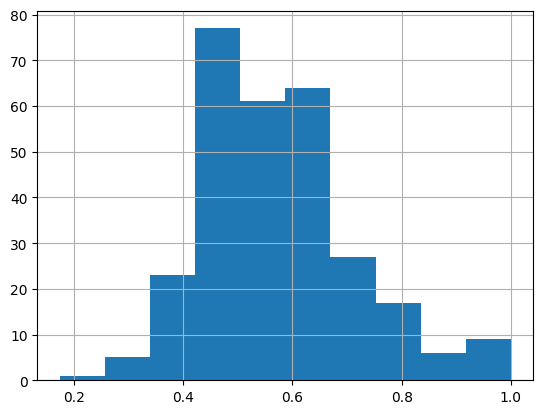

In [ ]:
print(df1['list_result'].mean())
df1['list_result'].hist()

In [ ]:
list_result = []
list1 = []
list2 = []
for i,j in zip(df_join_l3['level3_truth'], df_join_l3['level3_LLM']):
  result = jaccard_similarity(i,j)
  list_result.append(result)
  list1.append(i)
  list2.append(j)

df = pd.DataFrame()
df['level3_truth'] = list1
df['level3_LLM'] = list2
df['list_result'] = list_result
df

,level3_truth,level3_LLM,list_result
0,"Infrastruktur, ', ' Kualitas, ', ' Guru","' Pengawasan, ', ' Privasi, ', ' Keamanan",0.409091
1,"Authentication, ', ' Surveillance, ', ' Conse...","' Surveillance, ', ' Monitoring, ', ' Authenti...",0.772727
2,"Authentication, ', ' Surveillance, ', ' Conse...","' Authentication, ', ' Authorization, ', ' Sur...",0.809524
3,"Access, ', ' Equity, ', ' Sanitation","' Health, ', ' Sanitation, ', ' Access",0.650000
4,"Evaluación, ', ' Desempeño, ', ' Calidad","' Assessment, ', ' Evaluation, ', ' Examinations",0.583333
...,...,...,...
285,"Etnicidade, ', ' Territorialidade, ', ' Ident...","' Equidade', ' Acesso', ' QuilombolasJustifica...",0.400000
286,"Discriminación, ', ' Violencia, ', ' Exclusión","' Discriminación', ' Violencia', ' Odio",0.761905
287,"Diskriminasi, ', ' Upah, ', ' Pelecehan","' Diskriminasi', ' Kesetaraan Gender', ' Keker...",0.545455
288,"Perampasan, ', ' Kekerasan, ', ' Diskriminasi","' Tanah', ' Masyarakat Adat', ' Sengketa",0.375000


# original language code

In [ ]:
df_test_before_tune = df_join_l3.merge(df, how ='inner', on =['level3_truth','level3_LLM'])
df_test_before_tune

,Domain,level1,level2,level3_truth,country,language_code,Definition,level3_LLM,level3_translated,level3_translated2,level3_LLM_translated,level3_truth_translated,list_result
0,Pendidikan,Surveillance and Monitoring,law enforcement access to data,"Infrastruktur, ', ' Kualitas, ', ' Guru",Indonesia,id,"Privacy, in short, is the right to be free fro...","' Pengawasan, ', ' Privasi, ', ' Keamanan","'Oversight,', 'Privacy,', 'Security","Infrastructure, ',' quality, ',' teacher","'Oversight,', 'Privacy,', 'Security","Infrastructure, ',' quality, ',' teacher",0.409091
1,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Surveillance, ', ' Monitoring, ', ' Authenti...","' Surveillance, ', ' Monitoring, ', ' Authenti...","Authentication, ', ' Surveillance, ', ' Consent","' Surveillance, ', ' Monitoring, ', ' Authenti...","Authentication, ', ' Surveillance, ', ' Conse...",0.772727
2,Privacy and security,Surveillance and Monitoring,biometrics,"Authentication, ', ' Surveillance, ', ' Conse...",ALL,en,"Privacy, in short, is the right to be free fro...","' Authentication, ', ' Authorization, ', ' Sur...","' Authentication, ', ' Authorization, ', ' Sur...","Authentication, ', ' Surveillance, ', ' Consent","' Authentication, ', ' Authorization, ', ' Sur...","Authentication, ', ' Surveillance, ', ' Conse...",0.809524
3,Legal Human & Civil Rights,Public Health and Safety,disease prevention,"Access, ', ' Equity, ', ' Sanitation",Indonesia,en,Human rights are the rights one has simply for...,"' Health, ', ' Sanitation, ', ' Access","' Health, ', ' Sanitation, ', ' Access","Access, ', ' Equity, ', ' Sanitation","' Health, ', ' Sanitation, ', ' Access","Access, ', ' Equity, ', ' Sanitation",0.650000
4,Education,Curriculum and Quality,standardized testing,"Evaluación, ', ' Desempeño, ', ' Calidad",Mexico,en,Education encompasses formal and informal proc...,"' Assessment, ', ' Evaluation, ', ' Examinations","' Assessment, ', ' Evaluation, ', ' Examinations","Evaluación, ', ' Desempeño, ', ' Calidad","' Assessment, ', ' Evaluation, ', ' Examinations","Evaluación, ', ' Desempeño, ', ' Calidad",0.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
285,Educação,Categoria: ACESSO E Equidade,Educdação Quilombola,"Etnicidade, ', ' Territorialidade, ', ' Ident...",Brazil,pt,A educação abrange processos formais e informa...,"' Equidade', ' Acesso', ' QuilombolasJustifica...","'Equity', 'Access',' Quilombolasjustificative ...","Ethnicity, ',' territoriality, ',' identity","'Equity', 'Access',' Quilombolasjustificative ...","Ethnicity, ',' territoriality, ',' identity",0.400000
286,Derechos humanos y civiles legales,Categoría: Derechos LGBTIQ+,transfobia,"Discriminación, ', ' Violencia, ', ' Exclusión",Mexico,es,Los derechos humanos son los derechos que uno ...,"' Discriminación', ' Violencia', ' Odio","'Discrimination', 'violence', 'hate","Discrimination, ',' Violence, ',' Exclusion","'Discrimination', 'violence', 'hate","Discrimination, ',' Violence, ',' Exclusion",0.761905
287,Tenaga Kerja & Ketenagakerjaan,Kategori: Perlindungan Tenaga Kerja,Pekerja Perempuan,"Diskriminasi, ', ' Upah, ', ' Pelecehan",Indonesia,id,Tenaga kerja dan pekerjaan merujuk pada hubung...,"' Diskriminasi', ' Kesetaraan Gender', ' Keker...","'Discrimination', 'gender equality', 'violence","Discrimination, ',' wage, ',' harassment","'Discrimination', 'gender equality', 'violence","Discrimination, ',' wage, ',' harassment",0.545455
288,Hak Asasi Manusia & Sipil Hukum,Kategori: Hak Masyarakat Adat,Konflik Agraria,"Perampasan, ', ' Kekerasan, ', ' Diskriminasi",Indonesia,id,nan,"' Tanah', ' Masyarakat Adat', ' Sengketa","'Land', 'indigenous people', 'dispute","Deprivation, ',' violence, ',' discrimination","'Land', 'indigenous people', 'dispute","Deprivation, ',' violence, ',' discrimination",0.375000


0.5435939150086387


<Axes: >

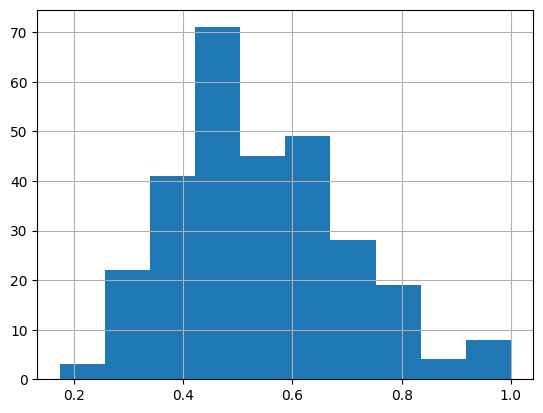

In [ ]:
print(df_test_before_tune['list_result'].mean())
df_test_before_tune['list_result'].hist()

# Step7: Fine-tune the Model

 - `source_model`: Specifies the base Gemini model version you want to fine-tune.
 - `train_dataset`: Path to your training data in JSONL format.

  *Optional parameters*
 - `validation_dataset`: If provided, this data is used to evaluate the model during tuning.
 - `tuned_model_display_name`: Display name for the tuned model.
 - `epochs`: The number of training epochs to run.
 - `learning_rate_multiplier`: A value to scale the learning rate during training.
 - `adapter_size` : Gemini supports Adapter length [1, 4], default value is 4.

In [ ]:
base_model = "gemini-2.5-flash" #gemini-1.5-flash-002
generation_model = GenerativeModel(base_model, generation_config= generation_config)

In [ ]:
tuned_model_display_name = "Test_Tuned_add_culture2"  # @param {type:"string"}

# Tune a model using `train` method.
sft_tuning_job = sft.train(
    source_model=base_model,
    train_dataset=f"{BUCKET_URI}/train/Train_add_Second5.jsonl",
    # Optional:
    validation_dataset=f"{BUCKET_URI}/val/Test_add_Second5.jsonl",
    tuned_model_display_name=tuned_model_display_name,
)

In [ ]:
# Get the tuning job info.
sft_tuning_job.to_dict()
sft_tuning_job_name = sft_tuning_job.resource_name

In [ ]:
%%time
# Wait for job completion
while not sft_tuning_job.refresh().has_ended:
    time.sleep(60)

CPU times: user 37min 11s, sys: 12.2 s, total: 37min 23s
Wall time: 1h 11min 12s


In [ ]:
# tuned model endpoint name
tuned_model_name = sft_tuning_job.tuned_model_name
tuned_model_endpoint_name = sft_tuning_job.tuned_model_endpoint_name

### Step7 [a]: Tuning and evaluation metrics


- `/train_total_loss`: Loss for the tuning dataset at a training step.
- `/train_fraction_of_correct_next_step_preds`: The token accuracy at a training step. A single prediction consists of a sequence of tokens. This metric measures the accuracy of the predicted tokens when compared to the ground truth in the tuning dataset.
- `/train_num_predictions`: Number of predicted tokens at a training step

#### Model evaluation metrics:

- `/eval_total_loss`: Loss for the evaluation dataset at an evaluation step.
- `/eval_fraction_of_correct_next_step_preds`: The token accuracy at an evaluation step. A single prediction consists of a sequence of tokens. This metric measures the accuracy of the predicted tokens when compared to the ground truth in the evaluation dataset.
- `/eval_num_predictions`: Number of predicted tokens at an evaluation step.

The metrics visualizations are available after the model tuning job completes. If you don't specify a validation dataset when you create the tuning job, only the visualizations for the tuning metrics are available.

In [ ]:
experiment_name = sft_tuning_job.experiment.resource_name

In [ ]:
# Locate Vertex AI Experiment and Vertex AI Experiment Run
experiment = aiplatform.Experiment(experiment_name=experiment_name)
filter_str = metadata_utils._make_filter_string(
    schema_title="system.ExperimentRun",
    parent_contexts=[experiment.resource_name],
)
experiment_run = context.Context.list(filter_str)[0]

In [ ]:
# Read data from Tensorboard
tensorboard_run_name = f"{experiment.get_backing_tensorboard_resource().resource_name}/experiments/{experiment.name}/runs/{experiment_run.name.replace(experiment.name, '')[1:]}"
tensorboard_run = aiplatform.TensorboardRun(tensorboard_run_name)
metrics = tensorboard_run.read_time_series_data()

In [ ]:
def get_metrics(metric: str = "/train_total_loss"):
    """
    Get metrics from Tensorboard.

    Args:
      metric: metric name, eg. /train_total_loss or /eval_total_loss.
    Returns:
      steps: list of steps.
      steps_loss: list of loss values.
    """
    loss_values = metrics[metric].values
    steps_loss = []
    steps = []
    for loss in loss_values:
        steps_loss.append(loss.scalar.value)
        steps.append(loss.step)
    return steps, steps_loss

In [ ]:
# Get Train and Eval Loss
train_loss = get_metrics(metric="/train_total_loss")
eval_loss = get_metrics(metric="/eval_total_loss")

In [ ]:
# Plot the train and eval loss metrics using Plotly python library

fig = make_subplots(
    rows=1, cols=2, shared_xaxes=True, subplot_titles=("Train Loss", "Eval Loss")
)

# Add traces
fig.add_trace(
    go.Scatter(x=train_loss[0], y=train_loss[1], name="Train Loss", mode="lines"),
    row=1,
    col=1,
)
fig.add_trace(
    go.Scatter(x=eval_loss[0], y=eval_loss[1], name="Eval Loss", mode="lines"),
    row=1,
    col=2,
)

# Add figure title
fig.update_layout(title="Train and Eval Loss", xaxis_title="Steps", yaxis_title="Loss")

# Set x-axis title
fig.update_xaxes(title_text="Steps")

# Set y-axes titles
fig.update_yaxes(title_text="Loss")

# Show plot
fig.show()

## Step8: Load the Tuned Model


In [ ]:
def l3_function_tuned(df_final, Definition):
  if True:
    tuned_genai_model = GenerativeModel(tuned_model_endpoint_name)
    list_1 = []
    list_2 = []
    list_3 = []
    for i,j,t,c,l,d in set(zip(df_final.Domain,df_final.level1,df_final.level2,df_final.country,df_final.language_code, df_final[f'{Definition}'])):
      response = tuned_genai_model.generate_content(prompt_function(i,j,t,c,l,d),generation_config=generation_config, safety_settings={
                    HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
                    HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
                    HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
                    HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
                })
      result = response.text
      #result = translator.translate(result, src=f'{Language_code}', dest='en').text
      try:
        #list_term = [list([list(result.split('1.'))[1].split('2.')[0].replace(":", "").replace('\n',''), list(result.split('2.'))[1].split('3.')[0].replace(":", "").replace('\n',''),list(result.split('3.'))[1].replace(":", "").replace('\n','')])]
        list_1.append(result)
        list_2.append(t)
        list_3.append(c)
      except:
        pass
    df_term_gen = pd.DataFrame()
    df_term_gen['list_1'] = list_1
    df_term_gen['list_2'] = list_2
    df_term_gen['country'] = list_3
    df_term_gen.columns = ['level3', 'level2','country']
    df_demo_1 = df_final.merge(df_term_gen,how='left', on=['level2','country'])
    df_demo_1['level3'] = df_demo_1['level3'].apply(lambda x: str(x).replace('[', '').replace(']', '').replace('*',''))
    #df_demo_1[['level3', 'rationale_for_level3']] = df_demo_1['level3'].str.split(';', n=1, expand=True)
    return df_demo_1
  else:
    print("State:", sft_tuning_job.state)
    print("Error:", sft_tuning_job.error)

df = l3_function_tuned(test_instances_domain_dimention[['Domain', 'level1', 'level2', 'country', 'language_code','Definition']],'Definition')
df

,Domain,level1,level2,country,language_code,Definition,level3
0,Legal Human & Civil Rights,Rights of Indigenous Peoples,customary law,Indonesia,en,Human rights are the rights one has simply for...,"Adat, ', ' Land, ', ' Autonomy\n\n"
1,Inclusión financiera y acceso a la financiación,Categoría: informalidad,TEMAS: Economía informal,Mexico,es,Esto significa que las personas y las empresas...,"Microcrédito, ', ' Bancarización, ', ' Vulner..."
2,Inclusión financiera y acceso a la financiación,Categoría: informalidad,TEMAS: Economía informal,Mexico,es,Esto significa que las personas y las empresas...,"Precariedad, ',' vulnerabilidad ',' desprotecc..."
3,Privasi dan Keamanan,Kategori: Pengawasan Pemerintah,Hak Asasi Manusia Dalam Konteks Pengawasan,Indonesia,id,"Singkatnya, privasi adalah hak untuk bebas dar...","Penyadapan, ', ' Data, ', ' Kebebasan\n\n"
4,Labor & Employment,Minimum Wage,enforcement of minimum wage laws,Mexico,en,Labor and employment refer to the relationship...,"Compliance, ', ' Inspections, ', ' Penalties\n\n"
...,...,...,...,...,...,...,...
273,Politics & Government,Parliamentary System,legislative process,India,en,Politics is the process by which people decide...,"Bills, ', ' Amendments, ', ' Committees\n\n"
274,Tenaga Kerja & Ketenagakerjaan,Kategori: Perlindungan Tenaga Kerja,Pekerja Migran,Indonesia,id,Tenaga kerja dan pekerjaan merujuk pada hubung...,"Eksploitasi, ', ' Perdagangan, ', ' Perlindun..."
275,Education,Educational Infrastructure,educational technology,Mexico,en,Education encompasses formal and informal proc...,"Access, ', ' Equity, ', ' Resources\n\n"
276,Education,Access and Equity,school enrollment rates,Brazil,en,Education encompasses formal and informal proc...,"Access, ', ' Inequality, ', ' Disparities\n\n"


In [ ]:
df_join_l3_tuned = test_instances_domain_dimention.merge(df[(df['level3']!= '')&(df['level3']!= '\n\n')][['Domain', 'level1', 'level2', 'country', 'language_code','level3']], how = 'inner', on = ['Domain', 'level1', 'level2', 'country', 'language_code'], suffixes=('_truth', '_LLM'))
df_join_l3_tuned['level3_LLM'] = df_join_l3_tuned['level3_LLM'].str.replace('\n\n', '')
df_join_l3_tuned

,Domain,level1,level2,level3_truth,country,language_code,Definition,level3_LLM
0,Legal Human & Civil Rights,Rights of Indigenous Peoples,customary law,"Adat, ', ' Ulayat, ', "" Masyarakat",Indonesia,en,Human rights are the rights one has simply for...,"Adat, ', ' Land, ', ' Autonomy"
1,Inclusión financiera y acceso a la financiación,Categoría: informalidad,TEMAS: Economía informal,"Microcrédito, ', ' Desbancarización, ', ' Vul...",Mexico,es,Esto significa que las personas y las empresas...,"Microcrédito, ', ' Bancarización, ', ' Vulner..."
2,Inclusión financiera y acceso a la financiación,Categoría: informalidad,TEMAS: Economía informal,"Microcrédito, ', ' Desbancarización, ', ' Vul...",Mexico,es,Esto significa que las personas y las empresas...,"Precariedad, ', ' Subregistro, ', ' Vulnerabi..."
3,Privasi dan Keamanan,Kategori: Pengawasan Pemerintah,Hak Asasi Manusia Dalam Konteks Pengawasan,"Privasi, ',' Kebebasan, ',' Akuntabilitas\n\n",Indonesia,id,"Singkatnya, privasi adalah hak untuk bebas dar...","Penyadapan, ', ' Data, ', ' Kebebasan"
4,Labor & Employment,Minimum Wage,enforcement of minimum wage laws,"Compliance, ', ' Inspections, ', ' Penalties",Mexico,en,Labor and employment refer to the relationship...,"Compliance, ', ' Inspections, ', ' Penalties"
...,...,...,...,...,...,...,...,...
273,Politics & Government,Parliamentary System,legislative process,"Bills, ', ' Debate, ', ' Voting",India,en,Politics is the process by which people decide...,"Bills, ', ' Amendments, ', ' Committees"
274,Tenaga Kerja & Ketenagakerjaan,Kategori: Perlindungan Tenaga Kerja,Pekerja Migran,"Eksploitasi, ', ' Kerentanan, ', ' Diskriminasi",Indonesia,id,Tenaga kerja dan pekerjaan merujuk pada hubung...,"Eksploitasi, ', ' Perdagangan, ', ' Hak"
275,Education,Educational Infrastructure,educational technology,"Access, ', ' Equity, ', ' Connectivity",Mexico,en,Education encompasses formal and informal proc...,"Access, ', ' Equity, ', ' Resources"
276,Education,Access and Equity,school enrollment rates,"Attendance, ', ' Inequality, ', ' Inclusion",Brazil,en,Education encompasses formal and informal proc...,"Access, ', ' Inequality, ', ' Disparities"


In [ ]:
for index, row in df_join_l3_tuned.iterrows():
    # Get the level1 and level2 values for this row
    level3_value = row['level3_LLM']
    level3_value2 = row['level3_truth']

    # Get the destination language code for this row
    dest_language_code = row['language_code']

    # Translate the level1 value
    translated_level3 = translator.translate(level3_value,src = dest_language_code, dest='en').text
    df_join_l3_tuned.loc[index, 'level3_translated'] = translated_level3

    translated_level32 = translator.translate(level3_value2,src = dest_language_code, dest='en').text
    df_join_l3_tuned.loc[index, 'level3_translated2'] = translated_level32

df_join_l3_tuned['level3_LLM_translated'] = df_join_l3_tuned.apply(lambda row: row['level3_LLM'] if row['language_code'] == 'en' else row['level3_translated'], axis=1)
df_join_l3_tuned['level3_truth_translated'] = df_join_l3_tuned.apply(lambda row: row['level3_truth'] if row['language_code'] == 'en' else row['level3_translated2'], axis=1)
df_join_l3_tuned

,Domain,level1,level2,level3_truth,country,language_code,Definition,level3_LLM,level3_translated,level3_translated2,level3_LLM_translated,level3_truth_translated
0,Legal Human & Civil Rights,Rights of Indigenous Peoples,customary law,"Adat, ', ' Ulayat, ', "" Masyarakat",Indonesia,en,Human rights are the rights one has simply for...,"Adat, ', ' Land, ', ' Autonomy","Adat, ', ' Land, ', ' Autonomy","Adat, ', ' Ulayat, ', "" Masyarakat","Adat, ', ' Land, ', ' Autonomy","Adat, ', ' Ulayat, ', "" Masyarakat"
1,Inclusión financiera y acceso a la financiación,Categoría: informalidad,TEMAS: Economía informal,"Microcrédito, ', ' Desbancarización, ', ' Vul...",Mexico,es,Esto significa que las personas y las empresas...,"Microcrédito, ', ' Bancarización, ', ' Vulner...","Microcredit, ',' banking, ',' vulnerability","Microcredit, ',' Discomblution, ',' Vulnerability","Microcredit, ',' banking, ',' vulnerability","Microcredit, ',' Discomblution, ',' Vulnerability"
2,Inclusión financiera y acceso a la financiación,Categoría: informalidad,TEMAS: Economía informal,"Microcrédito, ', ' Desbancarización, ', ' Vul...",Mexico,es,Esto significa que las personas y las empresas...,"Precariedad, ', ' Subregistro, ', ' Vulnerabi...","Precariousness, ',' sub -registration, ',' vul...","Microcredit, ',' Discomblution, ',' Vulnerability","Precariousness, ',' sub -registration, ',' vul...","Microcredit, ',' Discomblution, ',' Vulnerability"
3,Privasi dan Keamanan,Kategori: Pengawasan Pemerintah,Hak Asasi Manusia Dalam Konteks Pengawasan,"Privasi, ',' Kebebasan, ',' Akuntabilitas\n\n",Indonesia,id,"Singkatnya, privasi adalah hak untuk bebas dar...","Penyadapan, ', ' Data, ', ' Kebebasan","Tapping, ',' data, ',' freedom","Privacy, ',' Freedom, ',' Accountability","Tapping, ',' data, ',' freedom","Privacy, ',' Freedom, ',' Accountability"
4,Labor & Employment,Minimum Wage,enforcement of minimum wage laws,"Compliance, ', ' Inspections, ', ' Penalties",Mexico,en,Labor and employment refer to the relationship...,"Compliance, ', ' Inspections, ', ' Penalties","Compliance, ', ' Inspections, ', ' Penalties","Compliance, ', ' Inspections, ', ' Penalties","Compliance, ', ' Inspections, ', ' Penalties","Compliance, ', ' Inspections, ', ' Penalties"
...,...,...,...,...,...,...,...,...,...,...,...,...
273,Politics & Government,Parliamentary System,legislative process,"Bills, ', ' Debate, ', ' Voting",India,en,Politics is the process by which people decide...,"Bills, ', ' Amendments, ', ' Committees","Bills, ', ' Amendments, ', ' Committees","Bills, ', ' Debate, ', ' Voting","Bills, ', ' Amendments, ', ' Committees","Bills, ', ' Debate, ', ' Voting"
274,Tenaga Kerja & Ketenagakerjaan,Kategori: Perlindungan Tenaga Kerja,Pekerja Migran,"Eksploitasi, ', ' Kerentanan, ', ' Diskriminasi",Indonesia,id,Tenaga kerja dan pekerjaan merujuk pada hubung...,"Eksploitasi, ', ' Perdagangan, ', ' Hak","Exploitation, ',' trade, ',' right","Exploitation, ',' vulnerability, ',' discrimin...","Exploitation, ',' trade, ',' right","Exploitation, ',' vulnerability, ',' discrimin..."
275,Education,Educational Infrastructure,educational technology,"Access, ', ' Equity, ', ' Connectivity",Mexico,en,Education encompasses formal and informal proc...,"Access, ', ' Equity, ', ' Resources","Access, ', ' Equity, ', ' Resources","Access, ', ' Equity, ', ' Connectivity","Access, ', ' Equity, ', ' Resources","Access, ', ' Equity, ', ' Connectivity"
276,Education,Access and Equity,school enrollment rates,"Attendance, ', ' Inequality, ', ' Inclusion",Brazil,en,Education encompasses formal and informal proc...,"Access, ', ' Inequality, ', ' Disparities","Access, ', ' Inequality, ', ' Disparities","Attendance, ', ' Inequality, ', ' Inclusion","Access, ', ' Inequality, ', ' Disparities","Attendance, ', ' Inequality, ', ' Inclusion"


## Step9: Evaluation post model tuning

In [ ]:
# run evaluation
df_eval_cal = evaluation(df_join_l3_tuned)
df_eval_cal

,level3_truth,level3_LLM,list_result
0,"Adat, ', ' Ulayat, ', "" Masyarakat","Adat, ', ' Land, ', ' Autonomy",0.400000
1,"Microcrédito, ', ' Desbancarización, ', ' Vul...","Microcrédito, ', ' Bancarización, ', ' Vulner...",0.869565
2,"Microcrédito, ', ' Desbancarización, ', ' Vul...","Precariedad, ', ' Subregistro, ', ' Vulnerabi...",0.680000
3,"Privasi, ',' Kebebasan, ',' Akuntabilitas\n\n","Penyadapan, ', ' Data, ', ' Kebebasan",0.478261
4,"Compliance, ', ' Inspections, ', ' Penalties","Compliance, ', ' Inspections, ', ' Penalties",1.000000
...,...,...,...
273,"Bills, ', ' Debate, ', ' Voting","Bills, ', ' Amendments, ', ' Committees",0.550000
274,"Eksploitasi, ', ' Kerentanan, ', ' Diskriminasi","Eksploitasi, ', ' Perdagangan, ', ' Hak",0.681818
275,"Access, ', ' Equity, ', ' Connectivity","Access, ', ' Equity, ', ' Resources",0.736842
276,"Attendance, ', ' Inequality, ', ' Inclusion","Access, ', ' Inequality, ', ' Disparities",0.761905


In [ ]:
import re

def has_words(text):
  # Check if the text contains at least one word using regex
  if re.search(r"\b\w+\b", text):
    return True
  return False

filtered_df = df_eval_cal[df_eval_cal['level3_LLM'].apply(has_words)]
filtered_df

,level3_truth,level3_LLM,list_result
0,"Adat, ', ' Ulayat, ', "" Masyarakat","Adat, ', ' Land, ', ' Autonomy",0.400000
1,"Microcrédito, ', ' Desbancarización, ', ' Vul...","Microcrédito, ', ' Bancarización, ', ' Vulner...",0.869565
2,"Microcrédito, ', ' Desbancarización, ', ' Vul...","Precariedad, ', ' Subregistro, ', ' Vulnerabi...",0.680000
3,"Privasi, ',' Kebebasan, ',' Akuntabilitas\n\n","Penyadapan, ', ' Data, ', ' Kebebasan",0.478261
4,"Compliance, ', ' Inspections, ', ' Penalties","Compliance, ', ' Inspections, ', ' Penalties",1.000000
...,...,...,...
273,"Bills, ', ' Debate, ', ' Voting","Bills, ', ' Amendments, ', ' Committees",0.550000
274,"Eksploitasi, ', ' Kerentanan, ', ' Diskriminasi","Eksploitasi, ', ' Perdagangan, ', ' Hak",0.681818
275,"Access, ', ' Equity, ', ' Connectivity","Access, ', ' Equity, ', ' Resources",0.736842
276,"Attendance, ', ' Inequality, ', ' Inclusion","Access, ', ' Inequality, ', ' Disparities",0.761905


In [ ]:
list_result = []
list1 = []
list2 = []
for i,j in zip(df_join_l3_tuned['level3_truth_translated'], df_join_l3_tuned['level3_LLM_translated']):
  result = jaccard_similarity(i,j)
  list_result.append(result)
  list1.append(i)
  list2.append(j)

df1 = pd.DataFrame()
df1['level3_truth_translated'] = list1
df1['level3_LLM_translated'] = list2
df1['list_result'] = list_result
df1

,level3_truth_translated,level3_LLM_translated,list_result
0,"Adat, ', ' Ulayat, ', "" Masyarakat","Adat, ', ' Land, ', ' Autonomy",0.400000
1,"Microcredit, ',' Discomblution, ',' Vulnerability","Microcredit, ',' banking, ',' vulnerability",0.708333
2,"Microcredit, ',' Discomblution, ',' Vulnerability","Precariousness, ',' sub -registration, ',' vul...",0.640000
3,"Privacy, ',' Freedom, ',' Accountability","Tapping, ',' data, ',' freedom",0.480000
4,"Compliance, ', ' Inspections, ', ' Penalties","Compliance, ', ' Inspections, ', ' Penalties",1.000000
...,...,...,...
273,"Bills, ', ' Debate, ', ' Voting","Bills, ', ' Amendments, ', ' Committees",0.550000
274,"Exploitation, ',' vulnerability, ',' discrimin...","Exploitation, ',' trade, ',' right",0.625000
275,"Access, ', ' Equity, ', ' Connectivity","Access, ', ' Equity, ', ' Resources",0.736842
276,"Attendance, ', ' Inequality, ', ' Inclusion","Access, ', ' Inequality, ', ' Disparities",0.761905


0.7019487348136961


<Axes: >

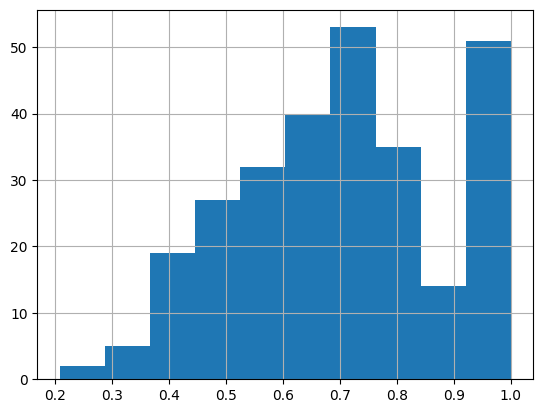

In [ ]:
# before tune is 55
print(df1['list_result'].mean())
df1['list_result'].hist()

0.6630993175225234


<Axes: >

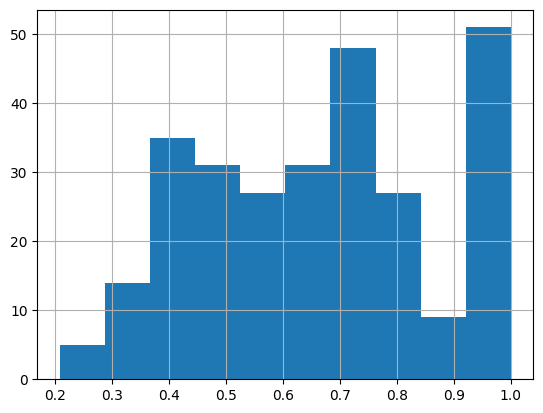

In [ ]:
# after tune is 50
print(df_eval_cal['list_result'].mean())
df_eval_cal['list_result'].hist()

In [ ]:
print('eval', df_eval_cal['list_result'].describe(), 'before', df_test_before_tune['list_result'].describe())

# imput EDU new topic for test

# Run the new data

In [ ]:
x = ''
def prompt_l1l2(domain, Country, Language_code, Definition):
  domain = domain # @param {isTemplate: true}
  Definition = Definition # @param {isTemplate: true}

  #Example = 'For hate speech one of the categories is dehumanization, and its topic expected would be subhuman, belittling, animals, germs, insect, bacteria, or another category could be Stereotyping, its corresponding topics would be listed as Prejudice,Bigotry,Discrimination,Labeling,Categorizing, Essentializing' # @param {isTemplate: true}
  level1_a = 'dehumanization' # @param {isTemplate: true}
  level2_a = 'Subhuman, belittling, animals, germs, insect, bacteria' # @param {isTemplate: true}

  level1_b = 'Public Health and Safety' # @param {isTemplate: true}
  level2_b = 'Healthcare Policies,Disease Prevention,Public Health Initiatives, Healthcare Access' # @param {isTemplate: true}

  Country = Country # @param {isTemplate: true}
  Language_code = Language_code #Please enter language code from previous session #@param {isTemplate: true}

  policy = domain
  translator = Translator()
  if Country == 'ALL':
    prompt = f'''You are a policy expert. Please analyze {policy} and provide a comprehensive list of categories and corresponding topics related to this domain given the definition of this domain is {Definition}.

                  Do not hallucinate or invent any links or sources.
                  If no actual links/sources are available, provide a clear and well-supported rationale for the generated topics and categories.
                  Strive for comprehensiveness in your analysis, covering a wide range of relevant perspectives and issues related to {policy}.

                  For example, your output please strictly follow the same format below（Category, Topics, Rationale） and do not add any more session besides Category, Topics, Rationale and keep the sequence of the session first say Category,then Topics, and Rationale, please do not add any more stuff, the format should EXACTLY look like the examples format below:

                Examples:
                    for hate speech domain,
                    Category: {level1_a}` (replace `{level1_a}` with your chosen category)
                    Topics: {level2_a}` (replace `{level2_a}` with the relevant topics for that category)
                    Rationale: [Explanation of why this category and topic are relevant to this domain , including links/sources if available]

                  for public interest domain,
                  Category: {level1_b}
                  Topics: {level2_b}
                  Rationale: [Explanation of why this category and topic are relevant to this domain, including actual links/sources if available, or a detailed rationale for generating these topics.]

                Notes:
                1. Check if all relevant categories and topics related to `{policy}` have been covered. If not, go back to step 2 and create another category entry using the same format, making sure there is always ":" following each key session such as Category:, Topics:, Rationale: ; please do not add "(" or ")" in the output.
                Continue this loop until you believe all significant aspects are addressed. Each iteration should add a new category entry. The loop terminates when a comprehensive list is created. Please making sure we include the example categories too
                2. Review the complete output to ensure it adheres strictly to the specified format and contains no hallucinations or invented information. do not limit yourself to specific number of categories to output, as long as its relevant and have sourced it should be included as long as not from hallucination
                Ensure all rationales are well-supported and clearly explain the relevance of each category and topic to the policy within the specified country.
                3. Output the complete list of categories, topics, and rationales in the specified format.

                  ... (repeat for each category)

                                      '''
  else:
    prompt = f'''
                As a policy expert specializing in {Country}, your task is to analyze the theme {policy} and provide a categorized list of relevant topics that specifically affect {Country} in this domain given the definition of this domain is {Definition}.
                Your output should strictly adhere to the specified format: (Category, Topics, Rationale). The rationale should explain the relevance of each category and topic to the policy within {Country},
                including citations or links in {Language_code} if available. Do not add any additional sessions or information beyond the requested format.

                # Step by Step instructions:
                1. Read the provided `Intent`, `Variable Names`, and `Other Context` sections carefully. Extract the values for `{Country}`, `{policy}`, and `{Language_code}`.
                Note that the `Other Context` provides an example format, but the instruction is to *only* use the format specified in the `Intent` section.
                2. Based on your knowledge of the specified `{Country}` and `{policy}`, brainstorm relevant categories and corresponding topics, etc.)
                that are specifically impacted by the policy within that country.
                3. The `Intent` section explicitly specifies the desired output format: `(Category, Topics, Rationale)`. Therefore, no other format needs to be considered.
                4. your output please strictly follow the same format below（Category, Topics, Rationale） and do not add any more session besides Category, Topics, Rationale and keep the sequence of the session first say Category,then Topics, and Rationale, please do not add any more stuff, the format should EXACTLY look like the examples format below:

                Examples:
                    for hate speech domain,
                    Category: {level1_a}` (replace `{level1_a}` with your chosen category)
                    Topics: {level2_a}` (replace `{level2_a}` with the relevant topics for that category)
                    Rationale: [Explanation of why this category and topic are relevant to this domain in {Country}, including links/sources in {Language_code} if available]

                    for public interest domain,
                    Category: {level1_b}
                    Topics: {level2_b}
                    Rationale: [Explanation of why this category and topic are relevant to this domain, including actual links/sources if available, or a detailed rationale for generating these topics.]


                5. Check if all relevant categories and topics related to `{policy}` in `{Country}` have been covered. If not, go back to step 2 and create another category entry using the same format, making sure there is always ":" following each key session such as Category:, Topics:, Rationale: ; please do not add "(" or ")" in the output.
                Continue this loop until you believe all significant aspects are addressed. Each iteration should add a new category entry. The loop terminates when a comprehensive list is created.Please making sure we include the example categories too
                6. Review the complete output to ensure it adheres strictly to the specified format and contains no hallucinations or invented information.
                Ensure all rationales are well-supported and clearly explain the relevance of each category and topic to the policy within the specified country.
                7. Output the complete list of categories, topics, and rationales in the specified format.




                                ...
                                      '''
  if Language_code == 'en':  # Changed line
    prompt = prompt
  else:
    translated_ita = translator.translate(prompt, src='en', dest=f'{Language_code}')
    prompt = translated_ita.text
  return prompt

In [ ]:
def l12_function(df_final2,Definition):
    all_results = [] # Initialize a list to store results from each row

    for index, row in df_final2.iterrows():
        domain = row['Domain']
        Country = row['country']
        Language_code = row['language_code']
        Definition = row[f'{Definition}']

        response = model.generate_content(prompt_l1l2(domain, Country, Language_code,Definition), safety_settings=safety_settings, request_options={"timeout": 1800})
        result = response.text

        list_split = list(result.split('\n'))  # Split the result based on newlines
        list_final = split_by_element(list_split, '') # Use your split_by_element function

        df_final = pd.DataFrame()  # Initialize an empty DataFrame for this row
        for i in list_final:  # Process each sublist
            if len(i) == 3:
                df = pd.DataFrame({
                    'topic': [i[1]],
                    'categories': [i[0]],
                    'rationale': [i[2]]
                })
                df_final = pd.concat([df_final, df], ignore_index=True)

        # Process df_final for the current domain
        df_final['topic'] = df_final['topic'].apply(lambda x: x.lower().replace('* ', '').replace('*', '').replace('topics:','').replace('themes:','').replace('topic:','').replace('theme:',''))
        df_final['categories'] = df_final['categories'].apply(lambda x: x.replace('*', '').replace('Category:','').replace('category:',''))
        df_final['rationale'] = df_final['rationale'].apply(lambda x: x.lower().replace('*', '').replace('rationale:','').replace('reasons:','').replace('reason:',''))
        df_final['domain'] = translator.translate(domain, src='en', dest=f'{Language_code}').text
        df_final['categories'] = df_final['categories'].apply(lambda x: x.replace('Category:','').replace('-',''))
        df_final['topic'] = df_final['topic'].str.split(', ')
        df_final = df_final.explode('topic', ignore_index=True)
        df_final['topic'] = df_final['topic'].apply(lambda x: x.replace('Topics:',''))
        df_final['country'] = Country
        df_final['language_code'] = Language_code
        df_final = df_final[['domain', 'categories', 'topic',  'country', 'language_code','rationale']]
        df_final.columns = ['domain', 'level1', 'level2',  'country', 'language_code','rationale']

        all_results.append(df_final) # Add this to the list

    combined_df = pd.concat(all_results, ignore_index=True) # Concatenate all results at the end
    return combined_df

In [ ]:
data = {'Domain': ['Culture (specific to user/country)'], 'country': ['ALL'], 'language_code': ['en'],
        'Definition': ['Gain an understanding of how culture manifests across countries and languages.'],
        'Definition_example': ['''Gain an understanding of how culture manifests across countries and languages. Artifacts or categories of culture:
                  Fashion/Style: includes clothing, hairstyles, and accessories
                  Cuisines: any food or dish
                  Architecture/Physical Spaces: Markets, houses, religious spaces, schools, parks, neighborhoods or buildings
                  Natural Landmarks: Any formation that exists in nature and was not human-made
                  Performance and Art: literary works, movements, writers, poets theatre, music, musicians, dance, dancers, characters, other performance art or visual art.
                  Religious rituals: rites around birth or death, rites of worship
                  Social practices/Customs: rites of passages, behaviors of daily life
                  Festivals: National or religious holidays or other festivities that mark seasons or life milestones
                  Sports: Games or sporting related events and people
                  Beliefs: Mythology, religious beliefs, deities
                  Important figures: political leaders, celebrities, historic figures
                  History: historic events, founding myths, folklore and stories
                  Communication: written or oral language, non verbal cues like gestures, sign language, patterns of speech or idioms
                  Social norms or practices:
                  Norms: standards or patterns of social behavior that are typical or expected
                  Etiquette: acceptable and unacceptable behaviors across various subcategories, such as dining, home visits and giving compliments
                  Organizational culture:
                  Relational structures: properties of stable social groups
                  Stereotypes
                  Associations of cultures to certain attributes, usually negative (Examples:  Asian, smart; Mexican, lazy; American, uneducated;)

          ''']

        }
df_eval2 = pd.DataFrame(data)
df_eval2

,Domain,country,language_code,Definition,Definition_example
0,Culture (specific to user/country),ALL,en,Gain an understanding of how culture manifests...,Gain an understanding of how culture manifests...


# Fine Tuned - Defintiion

In [ ]:
df_l1l2 = l12_function(df_eval2[['Domain', 'country', 'language_code','Definition']].drop_duplicates(),'Definition')
df_l1l2['Domain'] = df_l1l2['domain']
df_l1l2 = df_l1l2.merge(df_eval2[['Domain','Definition']], how = 'inner', on = 'Domain')
df_l3_new_tuned = l3_function_tuned(df_l1l2[['Domain', 'level1', 'level2', 'country', 'language_code','Definition']],'Definition')
df_l3_new_tuned

,Domain,level1,level2,country,language_code,Definition,level3
0,Culture (specific to user/country),Social Structures and Hierarchy,family structures,ALL,en,Gain an understanding of how culture manifests...,"Nuclear, ', ' Extended, ', ' Patriarchy\n\n\n\n"
1,Culture (specific to user/country),Social Structures and Hierarchy,social class,ALL,en,Gain an understanding of how culture manifests...,"Caste, ', ' Inequality, ', ' Privilege\n\n\n\n"
2,Culture (specific to user/country),Social Structures and Hierarchy,caste systems,ALL,en,Gain an understanding of how culture manifests...,"Untouchability, ', ' Discrimination, ', ' Ine..."
3,Culture (specific to user/country),Social Structures and Hierarchy,power dynamics,ALL,en,Gain an understanding of how culture manifests...,"Authority, ', ' Influence, ', ' Status\n\n\n\n"
4,Culture (specific to user/country),Social Structures and Hierarchy,age hierarchies,ALL,en,Gain an understanding of how culture manifests...,"Seniority, ', ' Respect, ', ' Authority\n\n\n\n"
5,Culture (specific to user/country),Social Structures and Hierarchy,gender roles.,ALL,en,Gain an understanding of how culture manifests...,"Patriarchy, ', ' Stereotypes, ', ' Inequality\..."
6,Culture (specific to user/country),Religious and Spiritual Beliefs,dominant religions,ALL,en,Gain an understanding of how culture manifests...,"Christianity, ', ' Islam, ', ' Hinduism\n\n\n\n"
7,Culture (specific to user/country),Religious and Spiritual Beliefs,religious practices,ALL,en,Gain an understanding of how culture manifests...,"Prayer, ', ' Rituals, ', ' Worship\n\n\n\n"
8,Culture (specific to user/country),Religious and Spiritual Beliefs,secularism,ALL,en,Gain an understanding of how culture manifests...,"Separation, ', ' Neutrality, ', ' Pluralism\n..."
9,Culture (specific to user/country),Religious and Spiritual Beliefs,religious tolerance,ALL,en,Gain an understanding of how culture manifests...,"Pluralism, ', ' Acceptance, ', ' Coexistence\..."


# Fine Tuned - Definition + example

In [ ]:
df_l1l2 = l12_function(df_eval2[['Domain', 'country', 'language_code','Definition_example']].drop_duplicates(),'Definition_example')
df_l1l2['Domain'] = df_l1l2['domain']
df_l1l2 = df_l1l2.merge(df_eval2[['Domain','Definition_example']], how = 'inner', on = 'Domain')
df_l3_new_tuned2 = l3_function_tuned(df_l1l2[['Domain', 'level1', 'level2', 'country', 'language_code','Definition_example']],'Definition_example')
df_l3_new_tuned2

,Domain,level1,level2,country,language_code,Definition_example,level3
0,Culture (specific to user/country),Fashion/Style,traditional clothing styles,ALL,en,Gain an understanding of how culture manifests...,"Kimono, ', ' Sari, ', ' Hanbok\n\n\n\n"
1,Culture (specific to user/country),Fashion/Style,contemporary fashion trends,ALL,en,Gain an understanding of how culture manifests...,"Streetwear, ', ' Athleisure, ', ' Sustainabil..."
2,Culture (specific to user/country),Fashion/Style,influence of global fashion,ALL,en,Gain an understanding of how culture manifests...,"Trends, ', ' Brands, ', ' Identity\n\n\n\n"
3,Culture (specific to user/country),Fashion/Style,regional variations in style,ALL,en,Gain an understanding of how culture manifests...,"Dialect, ', ' Accent, ', ' Slang\n\n\n\n"
4,Culture (specific to user/country),Fashion/Style,accessories and adornments,ALL,en,Gain an understanding of how culture manifests...,"Jewelry, ', ' Scarves, ', ' Hats\n\n\n\n"
...,...,...,...,...,...,...,...
109,Culture (specific to user/country),Organizational Culture,the relationship between organizational cultur...,ALL,en,Gain an understanding of how culture manifests...,"Values, ', ' Norms, ', ' Practices\n\n\n\n"
110,Culture (specific to user/country),Stereotypes,common stereotypes associated with the culture,ALL,en,Gain an understanding of how culture manifests...,"Reserved, ', ' Polite, ', ' Tea\n\n"
111,Culture (specific to user/country),Stereotypes,the origins and perpetuation of stereotypes,ALL,en,Gain an understanding of how culture manifests...,"Bias, ', ' Prejudice, ', ' Discrimination\n\n..."
112,Culture (specific to user/country),Stereotypes,the impact of stereotypes on social interactions,ALL,en,Gain an understanding of how culture manifests...,"Bias, ', ' Discrimination, ', ' Prejudice\n\n..."


# Gemini - Definition

In [ ]:
df_export = pipeline_run(df_eval2['Domain'][0], df_eval2['country'][0], df_eval2['language_code'][0], df_eval2['Definition'][0])
df_export

,domain,level1,level2,country,language_code,rationale,Definition,level3,rationale_for_level3
0,Culture (specific to user/country),Communication Styles,verbal communication (direct vs. indirect,ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Directness, ', ' Indirectness, ', ' Politeness",Rationale These keywords directly reflect the...
1,Culture (specific to user/country),Communication Styles,high-context vs. low-context),ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Communication, ', ' Culture, ', ' Context",Rationale These three words directly represen...
2,Culture (specific to user/country),Communication Styles,nonverbal communication (body language,ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Gestures, ', ' Posture, ', ' Eye contact",Rationale These keywords directly relate to n...
3,Culture (specific to user/country),Communication Styles,gestures,ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Body Language, ', ' Nonverbal, ', ' Communic...",Rationale These keywords directly relate to g...
4,Culture (specific to user/country),Communication Styles,eye contact),ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Gaze, ', ' Respect, ', ' Politeness",Rationale These keywords reflect cultural var...
5,Culture (specific to user/country),Communication Styles,silence and pauses,ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Nonverbal, ', ' Communication, ', ' Respect",Rationale These keywords reflect the cultural...
6,Culture (specific to user/country),Communication Styles,conversational turn-taking,ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Politeness, ', ' Interruption, ', ' Silence",Rationale These keywords reflect cultural var...
7,Culture (specific to user/country),Communication Styles,language formality,ALL,en,communication styles vary significantly acros...,Gain an understanding of how culture manifests...,"' Politeness, ', ' Formality, ', ' Register",Rationale These keywords directly reflect lev...
8,Culture (specific to user/country),Social Norms and Etiquette,greetings and salutations,ALL,en,understanding social norms and etiquette is ...,Gain an understanding of how culture manifests...,"' Greetings', ' Salutations', ' Etiquette",Rationale These keywords directly reflect the...
9,Culture (specific to user/country),Social Norms and Etiquette,table manners,ALL,en,understanding social norms and etiquette is ...,Gain an understanding of how culture manifests...,"' Etiquette, ', ' Customs, ', ' Protocol",Rationale These words directly relate to the ...


In [ ]:
df_export2 = pipeline_run(df_eval2['Domain'][0], df_eval2['country'][0], df_eval2['language_code'][0], df_eval2['Definition_example'][0])
df_export2

,domain,level1,level2,country,language_code,rationale,Definition,level3,rationale_for_level3
0,Culture (specific to user/country),Fashion/Style,traditional clothing styles,ALL,en,"fashion reflects cultural values, social stat...",Gain an understanding of how culture manifests...,"' Apparel', ' Attire', ' Garments",Rationale These keywords avoid direct duplica...
1,Culture (specific to user/country),Fashion/Style,contemporary fashion trends,ALL,en,"fashion reflects cultural values, social stat...",Gain an understanding of how culture manifests...,"' Streetwear, ', ' Athleisure, ', ' Sustainable",Rationale These keywords represent significan...
2,Culture (specific to user/country),Fashion/Style,influential designers,ALL,en,"fashion reflects cultural values, social stat...",Gain an understanding of how culture manifests...,"' Style Icons, ', ' Fashion Leaders, ', ' Tren...",Rationale These keywords directly relate to i...
3,Culture (specific to user/country),Fashion/Style,impact of globalization on fashion,ALL,en,"fashion reflects cultural values, social stat...",Gain an understanding of how culture manifests...,"' Globalization, ', ' Cultural, ', ' Fashion",Rationale These keywords directly address the...
4,Culture (specific to user/country),Fashion/Style,accessories and adornments,ALL,en,"fashion reflects cultural values, social stat...",Gain an understanding of how culture manifests...,"' Jewelry, ', ' Ornaments, ', ' Adornments",Rationale These words directly represent acce...
...,...,...,...,...,...,...,...,...,...
129,Culture (specific to user/country),Stereotypes,common stereotypes about the country,ALL,en,stereotypes are oversimplified generalization...,Gain an understanding of how culture manifests...,"' Prejudice, ', ' Misconceptions, ', ' Clichés",Rationale These words directly address the in...
130,Culture (specific to user/country),Stereotypes,origins of these stereotypes,ALL,en,stereotypes are oversimplified generalization...,Gain an understanding of how culture manifests...,"' Cultural, ', ' Origins, ', ' Stereotypes",Rationale These three words directly address ...
131,Culture (specific to user/country),Stereotypes,impact of stereotypes on intergroup relations,ALL,en,stereotypes are oversimplified generalization...,Gain an understanding of how culture manifests...,"' Prejudice, ', ' Bias, ', ' Discrimination",Rationale These keywords directly address the...
132,Culture (specific to user/country),Stereotypes,challenges to stereotypes,ALL,en,stereotypes are oversimplified generalization...,Gain an understanding of how culture manifests...,"' Prejudice, ', ' Bias, ', ' Discrimination",Rationale These three words directly address ...


In [ ]:
df_l3_new_tuned['source'] = 'fine-tuned_def'
df_l3_new_tuned2['source'] = 'fine-tuned_def_example'
df_export['source'] = 'gemini_def'
df_export2['source'] = 'gemini_def_example'
df_l3_new_tuned2.columns = ['domain', 'level1', 'level2', 'country', 'language_code',
       'Definition', 'level3', 'source']
df_l3_new_tuned.columns = ['domain', 'level1', 'level2', 'country', 'language_code',
       'Definition', 'level3',  'source']

df_export = df_export[['domain', 'level1', 'level2', 'country', 'language_code',
       'Definition', 'level3','source']]
df_export2 = df_export2[['domain', 'level1', 'level2', 'country', 'language_code',
       'Definition', 'level3','source']]
df_combine_eval = pd.concat([df_l3_new_tuned, df_l3_new_tuned2,df_export,df_export2])
df_combine_eval

,domain,level1,level2,country,language_code,Definition,level3,source
0,Culture (specific to user/country),Social Structures and Hierarchy,family structures,ALL,en,Gain an understanding of how culture manifests...,"Nuclear, ', ' Extended, ', ' Patriarchy\n\n\n\n",fine-tuned_def
1,Culture (specific to user/country),Social Structures and Hierarchy,social class,ALL,en,Gain an understanding of how culture manifests...,"Caste, ', ' Inequality, ', ' Privilege\n\n\n\n",fine-tuned_def
2,Culture (specific to user/country),Social Structures and Hierarchy,caste systems,ALL,en,Gain an understanding of how culture manifests...,"Untouchability, ', ' Discrimination, ', ' Ine...",fine-tuned_def
3,Culture (specific to user/country),Social Structures and Hierarchy,power dynamics,ALL,en,Gain an understanding of how culture manifests...,"Authority, ', ' Influence, ', ' Status\n\n\n\n",fine-tuned_def
4,Culture (specific to user/country),Social Structures and Hierarchy,age hierarchies,ALL,en,Gain an understanding of how culture manifests...,"Seniority, ', ' Respect, ', ' Authority\n\n\n\n",fine-tuned_def
...,...,...,...,...,...,...,...,...
129,Culture (specific to user/country),Stereotypes,common stereotypes about the country,ALL,en,Gain an understanding of how culture manifests...,"' Prejudice, ', ' Misconceptions, ', ' Clichés",gemini_def_example
130,Culture (specific to user/country),Stereotypes,origins of these stereotypes,ALL,en,Gain an understanding of how culture manifests...,"' Cultural, ', ' Origins, ', ' Stereotypes",gemini_def_example
131,Culture (specific to user/country),Stereotypes,impact of stereotypes on intergroup relations,ALL,en,Gain an understanding of how culture manifests...,"' Prejudice, ', ' Bias, ', ' Discrimination",gemini_def_example
132,Culture (specific to user/country),Stereotypes,challenges to stereotypes,ALL,en,Gain an understanding of how culture manifests...,"' Prejudice, ', ' Bias, ', ' Discrimination",gemini_def_example


# Add Rationale for review result

In [ ]:
#@title Import the Excel to Colab after Review  - Run this cell meaning we are updating the previous url reviewed result to the Colab
sheet_url = 'https://docs.google.com/spreadsheets/d/1lP-R-XbX5RgnrPPdghKZn_vSIcy_qxStE7yLJSCF1q8/edit?resourcekey=0-2xIqQty2VOqWyXtj-WyFRA&gid=1393464569#gid=1393464569'
creds, _ = default()
gc = gspread.authorize(creds)
# Replace with your actual sheet URL
sheet_url = sheet_url
# Open the spreadsheet
sh = gc.open_by_url(sheet_url)
# Select the worksheet (replace 'Sheet1' with the actual sheet name if needed)
worksheet = sh.worksheet('Sheet1')
data = worksheet.get_all_values()
df_review = pd.DataFrame(data[1:], columns=data[0])
# Print the DataFrame (optional)
df_review

In [ ]:
list_1 = []
list_2 = []
list_3 = []
list_4 = []
list_5 = []
for Domain,level1,level2,level3,Country, language_code in set(zip(df_combine_eval.domain, df_combine_eval.level1,df_combine_eval.level2,df_combine_eval.level3,df_combine_eval.country, df_combine_eval.language_code)):
  response = model.generate_content(f'''
          You are a social researcher who is expertise in understanding association of topics and domain,
          given LLM generated relationship on topics for example given Domain {Domain} , and the subdomain {level1} and  topic {level2} with their corresponding terms {level3},
          can you provide rationale or understand the association why LLM think there is an association between terms with the domain, subdomain and topics
          ?
          ''',safety_settings=safety_settings, request_options={"timeout": 1800})

  result = response.text
  list_1.append(Domain)
  list_2.append(result)
  list_3.append(level1)
  list_4.append(level2)
  list_5.append(level3)


df_combine_eval2 = pd.DataFrame()
df_combine_eval2['Domain'] = list_1
df_combine_eval2['rationale'] = list_2
df_combine_eval2['level1'] = list_3
df_combine_eval2['level2'] = list_4
df_combine_eval2['level3'] = list_5
df_combine_eval2 = df_combine_eval2.merge(df_combine_eval[['level3', 'source']], how = 'inner', on = 'level3')
df_combine_eval2

,Domain,rationale,level1,level2,level3,source
0,Culture (specific to user/country),"The LLM associates the terms ""Funeral,"" ""Buria...",Religious Rituals,death rites,"Funeral, ', ' Burial, ', ' Mourning\n\n\n\n",fine-tuned_def_example
1,Culture (specific to user/country),"The LLM associates the terms ""Body Language,"" ...",Communication Styles,gestures,"' Body Language, ', ' Nonverbal, ', ' Communic...",gemini_def
2,Culture (specific to user/country),"The LLM associates the terms ""Hello,"" ""Good mo...",Social Practices/Customs,greetings and salutations,"Hello, ', ' Good morning, ', ' How are you?\n...",fine-tuned_def_example
3,Culture (specific to user/country),"The LLM associates the terms ""Hello,"" ""Good mo...",Social Practices/Customs,greetings and salutations,"Hello, ', ' Good morning, ', ' How are you?\n...",fine-tuned_def_example
4,Culture (specific to user/country),"The LLM associates the terms ""Patriarchy,"" ""St...",Social Structures and Hierarchy,gender roles.,"Patriarchy, ', ' Stereotypes, ', ' Inequality\...",fine-tuned_def
...,...,...,...,...,...,...
387,Culture (specific to user/country),"The LLM associates the domain ""Culture (specif...",Language and Linguistics,language families and origins,"' Language, ', ' Family, ', ' Origins",gemini_def
388,Culture (specific to user/country),"The LLM associates the terms ""Family,"" ""Struct...",Family and Kinship,impact of social changes on family structures,"' Family, ', ' Structure, ', ' Transformation",gemini_def
389,Culture (specific to user/country),"The LLM associates the terms ""Luxury,"" ""Brand,...",Fashion/Style,social status and clothing.,"Luxury, ', ' Brand, ', ' Designer\n\n\n\n",fine-tuned_def_example
390,Culture (specific to user/country),"The LLM associates ""Etiquette,"" ""Customs,"" and...",Social Norms or Practices: Norms,social expectations,"' Etiquette, ', ' Customs, ', ' Norms",gemini_def_example
